In [1]:
import sys
from pathlib import Path
from pprint import pprint
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

# Make sure the uploaded modules are importable
sys.path.insert(0, "/mnt/data")

from noninteracting import KagomeNagaosa
from patching import FSPatcher, plot_patchset
from interaction import BareExtendedHubbard
from frg_flow import BareVertexFromInteraction, FRGFlowSolver
import sys
sys.path.insert(0, "/mnt/data")

# Patch

Patch counts: {'up': 3, 'dn': 3}
mu used for contour (up/dn): 0.0 0.0
gauge method (up/dn): manual_exact_M_hex_3_dropDupM manual_exact_M_hex_3_dropDupM

===== exact M6 anchors in centered 1BZ =====
M0: k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ]
M1: k=[ 0.       -1.813799] | k_can=[0.       1.813799]
M2: k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699]
M3: k=[1.570796 0.9069  ] | k_can=[1.570796 0.9069  ]
M4: k=[0.       1.813799] | k_can=[0.       1.813799]
M5: k=[-1.570796  0.9069  ] | k_can=[1.570796 2.720699]

===== kept indices in full loop =====
[0, 1, 2]

===== up exact-M3 patches =====
id= 0 | k=[-1.570796 -0.9069  ] | k_can=[1.570796 0.9069  ] | E=1.0947644253e-47 | |vF|=4.736669e-16 | w=[0. 1. 0.]
id= 1 | k=[ 0.       -1.813799] | k_can=[0.       1.813799] | E=1.0344233826e-31 | |vF|=3.449541e-16 | w=[1. 0. 0.]
id= 2 | k=[ 1.570796 -0.9069  ] | k_can=[1.570796 2.720699] | E=1.4997597827e-32 | |vF|=2.255553e-16 | w=[0. 0. 1.]

===== dn exact-M3 patches =====
id= 0 |

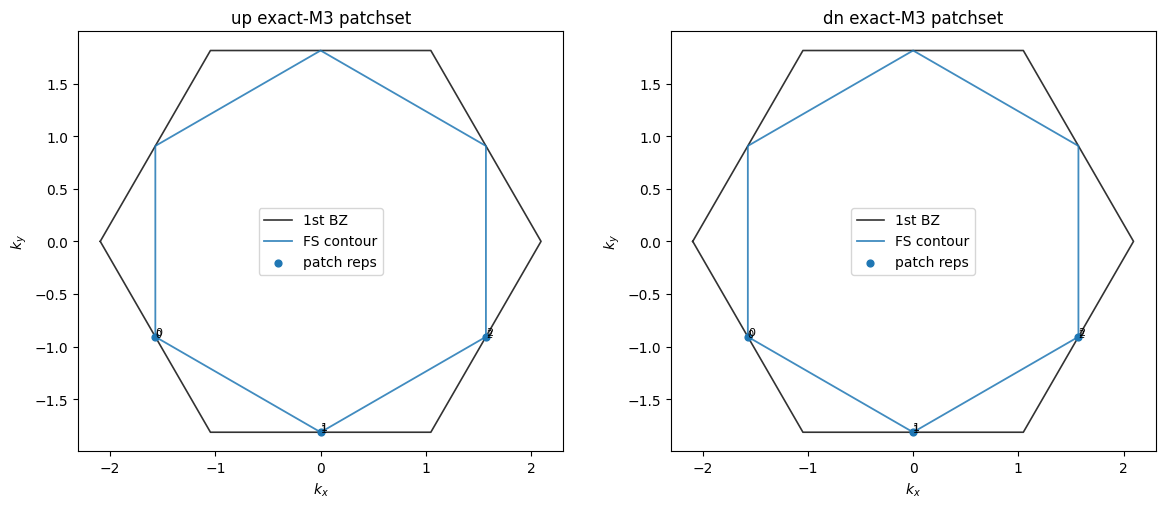

In [485]:
# ============================================================
# Manual exact-M patchsets on standard centered 1BZ hexagon
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from patching import PatchPoint, PatchSet, plot_patchset

model = KagomeNagaosa(MODEL_PARAMS, spin=True, B=None)

# ------------------------------------------------------------
# basic helpers
# ------------------------------------------------------------
def _sector_eig(model, k_cart, orbital_slice, band_index):
    kx, ky = float(k_cart[0]), float(k_cart[1])
    H = np.asarray(model.Hk(kx, ky), dtype=complex)
    Hs = H[orbital_slice, orbital_slice]
    evals, evecs = np.linalg.eigh(Hs)
    u = np.asarray(evecs[:, band_index], dtype=complex)
    u = u / np.linalg.norm(u)
    return float(evals[band_index]), u

def _orbital_weight(u):
    w = np.abs(np.asarray(u, dtype=complex))**2
    return w / np.sum(w)

def _cart_to_red(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    return np.linalg.solve(B, np.asarray(k, dtype=float))

def _finite_diff_velocity(model, k_cart, orbital_slice, band_index, h=1e-6):
    kx, ky = float(k_cart[0]), float(k_cart[1])

    def band_energy(x, y):
        H = np.asarray(model.Hk(x, y), dtype=complex)
        Hs = H[orbital_slice, orbital_slice]
        evals, _ = np.linalg.eigh(Hs)
        return float(evals[band_index])

    vx = (band_energy(kx + h, ky) - band_energy(kx - h, ky)) / (2*h)
    vy = (band_energy(kx, ky + h) - band_energy(kx, ky - h)) / (2*h)
    return np.array([vx, vy], dtype=float)


# ------------------------------------------------------------
# reciprocal helpers (only for identifying duplicate M anchors)
# ------------------------------------------------------------
def _wrap_unit_interval(x, tol=1e-12):
    x = np.asarray(x, dtype=float)
    x = x - np.floor(x)
    x[np.isclose(x, 1.0, atol=tol)] = 0.0
    x[np.isclose(x, 0.0, atol=tol)] = 0.0
    return x

def _canonicalize_k_mod_G(model, k):
    B = np.column_stack([
        np.asarray(model.b1, dtype=float),
        np.asarray(model.b2, dtype=float),
    ])
    uv = np.linalg.solve(B, np.asarray(k, dtype=float))
    uv = _wrap_unit_interval(uv)
    k_can = B @ uv
    k_can[np.isclose(k_can, 0.0, atol=1e-12)] = 0.0
    return k_can


# ------------------------------------------------------------
# 1BZ geometry
# ------------------------------------------------------------
def hex_bz_vertices(model):
    """
    Standard centered 1BZ hexagon vertices for triangular/kagome reciprocal lattice.

    For reciprocal vectors b1, b2, the Wigner-Seitz 1BZ vertices are:
        ±(2b1-b2)/3, ±(b1+b2)/3, ±(-b1+2b2)/3
    """
    b1 = np.asarray(model.b1, dtype=float)
    b2 = np.asarray(model.b2, dtype=float)

    verts = np.array([
        (2*b1 - b2) / 3.0,
        (b1 + b2) / 3.0,
        (-b1 + 2*b2) / 3.0,
        -(2*b1 - b2) / 3.0,
        -(b1 + b2) / 3.0,
        -(-b1 + 2*b2) / 3.0,
    ], dtype=float)

    ang = np.arctan2(verts[:, 1], verts[:, 0])
    order = np.argsort(ang)
    return verts[order]


def exact_M6_points_1bz(model):
    """
    6 geometric M points on the boundary of the standard centered 1BZ hexagon.
    Each M point is the midpoint of one hexagon edge.
    """
    V = hex_bz_vertices(model)
    M = []

    n = len(V)
    for i in range(n):
        v0 = V[i]
        v1 = V[(i + 1) % n]
        M.append(0.5 * (v0 + v1))

    M = np.asarray(M, dtype=float)

    # keep consistent cyclic order
    ang = np.arctan2(M[:, 1], M[:, 0])
    order = np.argsort(ang)
    return M[order]


def exact_M_hex_loop_points(model, points_per_edge=1):
    """
    Build a manual hex loop from the 6 exact M points on the centered 1BZ.

    points_per_edge = 1  ->  6 patches  (6 exact M points)
    points_per_edge = 2  -> 12 patches
    points_per_edge = 4  -> 24 patches

    Total patch number = 6 * points_per_edge
    """
    if points_per_edge < 1:
        raise ValueError("points_per_edge must be >= 1")

    M6 = exact_M6_points_1bz(model)
    pts = []

    n = len(M6)
    for i in range(n):
        k0 = M6[i]
        k1 = M6[(i + 1) % n]

        # put points_per_edge points on each M-to-M segment:
        # t = 0, 1/p, 2/p, ..., (p-1)/p
        # exclude t=1 to avoid duplicating the next M point
        for m in range(points_per_edge):
            t = m / points_per_edge
            k = (1.0 - t) * k0 + t * k1
            pts.append(k)

    return np.asarray(pts, dtype=float)


def _hex_bz_vertices_for_plot(model):
    return hex_bz_vertices(model)


# ------------------------------------------------------------
# only remove duplicated M anchors from patch reps
# ------------------------------------------------------------
def _patch_keep_indices_remove_duplicate_M_anchors(model, points_per_edge, tol=1e-10):
    """
    Return indices to KEEP among the standard exact-M loop points.

    Important:
    - This function assumes the loop K_full is built exactly by exact_M_hex_loop_points.
    - Only the 6 M-anchor points are checked for modulo-G duplication:
          0, p, 2p, 3p, 4p, 5p
      where p = points_per_edge.
    - All non-anchor points are always kept.
    """
    p = int(points_per_edge)
    n_full = 6 * p
    keep = np.ones(n_full, dtype=bool)

    anchor_ids = [i * p for i in range(6)]
    M6 = exact_M6_points_1bz(model)

    seen_classes = []
    for local_anchor_idx, global_idx in enumerate(anchor_ids):
        k = M6[local_anchor_idx]
        k_can = _canonicalize_k_mod_G(model, k)

        duplicated = False
        for q_can in seen_classes:
            if np.linalg.norm(k_can - q_can) < tol:
                duplicated = True
                break

        if duplicated:
            keep[global_idx] = False
        else:
            seen_classes.append(k_can)

    return np.flatnonzero(keep)


# ------------------------------------------------------------
# patchset builder
# ------------------------------------------------------------
def build_exactM_patchset(
    model,
    orbital_slice,
    band_index,
    points_per_edge=1,
    remove_duplicate_M_modG=False,
):
    # 1) build the FULL standard loop exactly as in the original code
    K_full = exact_M_hex_loop_points(model, points_per_edge=points_per_edge)

    # 2) only patch reps may be reduced; contour stays the original full loop
    if remove_duplicate_M_modG:
        keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(
            model,
            points_per_edge=points_per_edge,
        )
        K_patch = K_full[keep_idx]
    else:
        keep_idx = np.arange(len(K_full))
        K_patch = K_full

    bz_vertices = _hex_bz_vertices_for_plot(model)

    patches = []
    for pid, k in enumerate(K_patch):
        e, u = _sector_eig(model, k, orbital_slice, band_index)
        vF = _finite_diff_velocity(model, k, orbital_slice, band_index)

        patches.append(
            PatchPoint(
                patch_id=pid,
                k_cart=np.asarray(k, dtype=float),
                k_red=_cart_to_red(model, k),
                energy=e,
                vF=vF,
                vF_norm=float(np.linalg.norm(vF)),
                eigvec=u,
                orbital_weight=_orbital_weight(u),
            )
        )

    npatch = len(K_patch)
    suffix = "_dropDupM" if remove_duplicate_M_modG else ""
    return PatchSet(
        mu=0.0,
        mu_used_for_contour=0.0,
        band_index=int(band_index),
        filling=np.nan,
        patches=patches,
        fs_contour_k=np.asarray(K_full, dtype=float),   # <- keep original contour
        bz_vertices=np.asarray(bz_vertices, dtype=float),
        b1=np.asarray(model.b1, dtype=float),
        b2=np.asarray(model.b2, dtype=float),
        gauge_method=f"manual_exact_M_hex_{npatch}{suffix}",
        gauge_loop_phase=0.0,
    )


# ------------------------------------------------------------
# choose patch density here
# ------------------------------------------------------------
POINTS_PER_EDGE = 1   # 1->6, 2->12, 4->24
REMOVE_DUPLICATE_M_MODG = True

patchsets = {
    "up": build_exactM_patchset(
        model,
        UP_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    ),
    "dn": build_exactM_patchset(
        model,
        DN_SLICE,
        LOCAL_BAND_INDEX,
        points_per_edge=POINTS_PER_EDGE,
        remove_duplicate_M_modG=REMOVE_DUPLICATE_M_MODG,
    ),
}

NPATCH = patchsets["up"].Npatch


# ------------------------------------------------------------
# print info
# ------------------------------------------------------------
print("Patch counts:", {k: v.Npatch for k, v in patchsets.items()})
print("mu used for contour (up/dn):", patchsets["up"].mu_used_for_contour, patchsets["dn"].mu_used_for_contour)
print("gauge method (up/dn):", patchsets["up"].gauge_method, patchsets["dn"].gauge_method)

print("\n===== exact M6 anchors in centered 1BZ =====")
M6 = exact_M6_points_1bz(model)
for i, k in enumerate(M6):
    print(
        f"M{i}: k={np.round(k, 6)} | "
        f"k_can={np.round(_canonicalize_k_mod_G(model, k), 6)}"
    )

if REMOVE_DUPLICATE_M_MODG:
    keep_idx = _patch_keep_indices_remove_duplicate_M_anchors(model, POINTS_PER_EDGE)
    print("\n===== kept indices in full loop =====")
    print(keep_idx.tolist())

for spin in ["up", "dn"]:
    print(f"\n===== {spin} exact-M{NPATCH} patches =====")
    for p in patchsets[spin].patches:
        print(
            f"id={p.patch_id:2d} | "
            f"k={np.round(p.k_cart, 6)} | "
            f"k_can={np.round(_canonicalize_k_mod_G(model, p.k_cart), 6)} | "
            f"E={p.energy:.10e} | "
            f"|vF|={p.vF_norm:.6e} | "
            f"w={np.round(p.orbital_weight, 6)}"
        )


# ------------------------------------------------------------
# neighbor distance sanity check (patch reps only)
# ------------------------------------------------------------
for spin in ["up", "dn"]:
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)
    d = np.linalg.norm(np.roll(ks, -1, axis=0) - ks, axis=1)
    print(f"\n===== {spin} neighbor distances (patch reps only) =====")
    print(np.round(d, 8))


# ------------------------------------------------------------
# plot
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, spin in zip(axes, ["up", "dn"]):
    plot_patchset(
        patchsets[spin],
        ax=ax,
        show_contour=True,   # contour is now still the original full loop
        show_velocity=False,
        show_bz=True
    )
    ks = np.array([p.k_cart for p in patchsets[spin].patches], dtype=float)

    for i, k in enumerate(ks):
        ax.text(k[0], k[1], str(i), fontsize=8, ha="left", va="bottom")

    ax.set_title(f"{spin} exact-M{NPATCH} patchset")

plt.tight_layout()
plt.show()

PATCHSETS = patchsets

# Bare Level Kernel

In [119]:
solver_U6, builder_U6 = build_bare_solver_builder(U=6.0, V=0.0)
solver_V4, builder_V4 = build_bare_solver_builder(U=0.0, V=4.0)

pp_valid_ids, pp_invalid_ids, df_pp = get_valid_subspace_ids(solver_U6, QM1, channel="pp")
ph_valid_ids, ph_invalid_ids, df_ph = get_valid_subspace_ids(solver_U6, QM1, channel="ph")
print("QM0 =", np.array2string(Q0, precision=10))
print("QM1 =", np.array2string(QM1, precision=10))
print("\nPP valid ids:", pp_valid_ids.tolist())
print("PP invalid ids:", pp_invalid_ids.tolist())
print("\nPH valid ids:", ph_valid_ids.tolist())
print("PH invalid ids:", ph_invalid_ids.tolist())

display(df_pp)
display(df_ph)

QM1 = [0.           1.8137993642]

PP valid ids: [0, 8, 9, 10, 11, 18, 19, 20]
PP invalid ids: [1, 2, 3, 4, 5, 6, 7, 12, 13, 14, 15, 16, 17]

PH valid ids: [0, 8, 9, 10, 11, 18, 19, 20]
PH invalid ids: [1, 2, 3, 4, 5, 6, 7, 12, 13, 14, 15, 16, 17]


,patch,partner,valid,residual
0,0,8,True,4.440892e-16
1,1,-1,False,inf
2,2,-1,False,inf
3,3,-1,False,inf
4,4,-1,False,inf
5,5,-1,False,inf
6,6,-1,False,inf
7,7,-1,False,inf
8,8,0,True,4.440892e-16
9,9,11,True,0.000000e+00


,patch,partner,valid,residual
0,0,8,True,5.551115e-16
1,1,-1,False,inf
2,2,-1,False,inf
3,3,-1,False,inf
4,4,-1,False,inf
5,5,-1,False,inf
6,6,-1,False,inf
7,7,-1,False,inf
8,8,0,True,4.440892e-16
9,9,20,True,4.440892e-16


## QM1

Restricted Kpp(QM1) : U=6, V=0
  shape: (8, 8)
  max_abs: 3.0
  mean_abs: 1.092830085889911
  fro_norm: 12.000000000000002
  spec_radius_abs: 12.0
  max_real_eval: 12.0
Restricted Kpp(QM1) : U=0, V=4
  shape: (8, 8)
  max_abs: 8.0
  mean_abs: 4.0
  fro_norm: 35.77708763999664
  spec_radius_abs: 31.99999999999999
  max_real_eval: 31.99999999999999


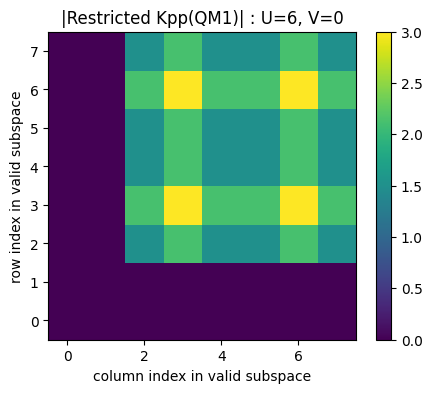

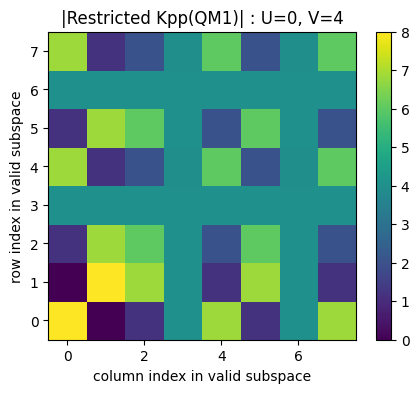

Top entries: U=6, V=0


,row,col,value,abs
0,3,3,3.00000+0.00000j,3.00000
1,3,6,3.00000+0.00000j,3.00000
2,6,3,3.00000+0.00000j,3.00000
3,6,6,3.00000+0.00000j,3.00000
4,6,5,2.12132+0.00000j,2.12132
5,6,2,2.12132+0.00000j,2.12132
6,3,5,2.12132+0.00000j,2.12132
7,3,2,2.12132+0.00000j,2.12132
8,5,3,2.12132+0.00000j,2.12132
9,5,6,2.12132+0.00000j,2.12132


Top entries: U=0, V=4


,row,col,value,abs
0,0,0,8.000000+0.000000j,8.000000
1,1,1,8.000000+0.000000j,8.000000
2,0,7,6.828427+0.000000j,6.828427
3,0,4,-6.828427+0.000000j,6.828427
4,1,2,6.828427+0.000000j,6.828427
5,1,5,-6.828427+0.000000j,6.828427
6,2,1,6.828427+0.000000j,6.828427
7,4,0,-6.828427+0.000000j,6.828427
8,5,1,-6.828427+0.000000j,6.828427
9,7,0,6.828427+0.000000j,6.828427


In [155]:
ker_pp_U6 = builder_U6.pp_block(
    QM1,
    incoming_pair=("up", "dn"),
    outgoing_pair=("up", "dn"),
)
ker_pp_V4 = builder_V4.pp_block(
    QM1,
    incoming_pair=("up", "dn"),
    outgoing_pair=("up", "dn"),
)

Kpp_U6 = np.asarray(ker_pp_U6.matrix)
Kpp_V4 = np.asarray(ker_pp_V4.matrix)

Kpp_U6_sub = Kpp_U6[np.ix_(pp_valid_ids, pp_valid_ids)]
Kpp_V4_sub = Kpp_V4[np.ix_(pp_valid_ids, pp_valid_ids)]

pp_stats_U6 = summarize_restricted_kernel(Kpp_U6_sub, title="Restricted Kpp(QM1) : U=6, V=0")
pp_stats_V4 = summarize_restricted_kernel(Kpp_V4_sub, title="Restricted Kpp(QM1) : U=0, V=4")

plot_kernel_abs(Kpp_U6_sub, title="|Restricted Kpp(QM1)| : U=6, V=0")
plot_kernel_abs(Kpp_V4_sub, title="|Restricted Kpp(QM1)| : U=0, V=4")

print("Top entries: U=6, V=0")
display(top_entries_df(Kpp_U6_sub, topn=20))

print("Top entries: U=0, V=4")
display(top_entries_df(Kpp_V4_sub, topn=20))

Restricted Kph(QM1) : U=6, V=0
  shape: (8, 8)
  max_abs: 3.0
  mean_abs: 1.092830085889911
  fro_norm: 12.000000000000002
  spec_radius_abs: 12.0
  max_real_eval: 12.0
Restricted Kph(QM1) : U=0, V=4
  shape: (8, 8)
  max_abs: 8.0
  mean_abs: 4.0
  fro_norm: 39.191835884530846
  spec_radius_abs: 31.999999999999993
  max_real_eval: 6.198481781073318e-15


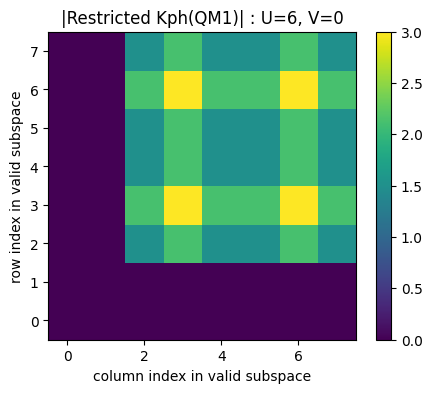

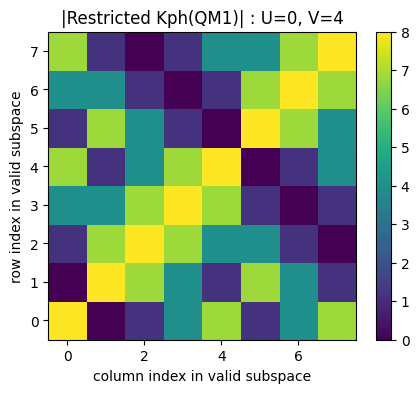

Top entries: U=6, V=0


,row,col,value,abs
0,3,3,3.00000+0.00000j,3.00000
1,3,6,3.00000+0.00000j,3.00000
2,6,3,3.00000+0.00000j,3.00000
3,6,6,3.00000+0.00000j,3.00000
4,2,6,2.12132+0.00000j,2.12132
5,2,3,2.12132+0.00000j,2.12132
6,3,5,2.12132+0.00000j,2.12132
7,3,7,2.12132+0.00000j,2.12132
8,5,3,2.12132+0.00000j,2.12132
9,5,6,2.12132+0.00000j,2.12132


Top entries: U=0, V=4


,row,col,value,abs
0,0,0,-8.000000+0.000000j,8.000000
1,1,1,-8.000000+0.000000j,8.000000
2,3,3,-8.000000+0.000000j,8.000000
3,2,2,-8.000000+0.000000j,8.000000
4,6,6,-8.000000+0.000000j,8.000000
5,7,7,-8.000000+0.000000j,8.000000
6,5,5,-8.000000+0.000000j,8.000000
7,4,4,-8.000000+0.000000j,8.000000
8,2,3,-6.828427+0.000000j,6.828427
9,5,6,-6.828427+0.000000j,6.828427


In [157]:
ker_ph_U6 = builder_U6.phd_block(
    QM1,
    incoming_bilinear=("up", "up"),
    outgoing_bilinear=("dn", "dn"),
)
ker_ph_V4 = builder_V4.phd_block(
    QM1,
    incoming_bilinear=("up", "up"),
    outgoing_bilinear=("up", "up"),
)

Kph_U6 = np.asarray(ker_ph_U6.matrix)
Kph_V4 = np.asarray(ker_ph_V4.matrix)

Kph_U6_sub = Kph_U6[np.ix_(ph_valid_ids, ph_valid_ids)]
Kph_V4_sub = Kph_V4[np.ix_(ph_valid_ids, ph_valid_ids)]

ph_stats_U6 = summarize_restricted_kernel(Kph_U6_sub, title="Restricted Kph(QM1) : U=6, V=0")
ph_stats_V4 = summarize_restricted_kernel(Kph_V4_sub, title="Restricted Kph(QM1) : U=0, V=4")

plot_kernel_abs(Kph_U6_sub, title="|Restricted Kph(QM1)| : U=6, V=0")
plot_kernel_abs(Kph_V4_sub, title="|Restricted Kph(QM1)| : U=0, V=4")

print("Top entries: U=6, V=0")
display(top_entries_df(Kph_U6_sub, topn=20))

print("Top entries: U=0, V=4")
display(top_entries_df(Kph_V4_sub, topn=20))

In [159]:
compare_df = pd.DataFrame([
    {
        "kernel": "Kpp(QM1)",
        "case": "U=6,V=0",
        **pp_stats_U6,
    },
    {
        "kernel": "Kpp(QM1)",
        "case": "U=0,V=4",
        **pp_stats_V4,
    },
    {
        "kernel": "Kph(QM1)",
        "case": "U=6,V=0",
        **ph_stats_U6,
    },
    {
        "kernel": "Kph(QM1)",
        "case": "U=0,V=4",
        **ph_stats_V4,
    },
])

display(compare_df)

,kernel,case,shape,max_abs,mean_abs,fro_norm,spec_radius_abs,max_real_eval
0,Kpp(QM1),"U=6,V=0","(8, 8)",3.0,1.09283,12.000000,12.0,1.200000e+01
1,Kpp(QM1),"U=0,V=4","(8, 8)",8.0,4.00000,35.777088,32.0,3.200000e+01
2,Kph(QM1),"U=6,V=0","(8, 8)",3.0,1.09283,12.000000,12.0,1.200000e+01
3,Kph(QM1),"U=0,V=4","(8, 8)",8.0,4.00000,39.191836,32.0,6.198482e-15


## Q0

Restricted Kpp(Q0) : U=6, V=0
  shape: (8, 8)
  max_abs: 6.0
  mean_abs: 3.0
  fro_norm: 26.832815729997478
  spec_radius_abs: 24.00000000000001
  max_real_eval: 24.00000000000001
Restricted Kpp(Q0) : U=0, V=4
  shape: (8, 8)
  max_abs: 4.0
  mean_abs: 1.457106781186548
  fro_norm: 16.0
  spec_radius_abs: 16.000000000000004
  max_real_eval: 16.000000000000004


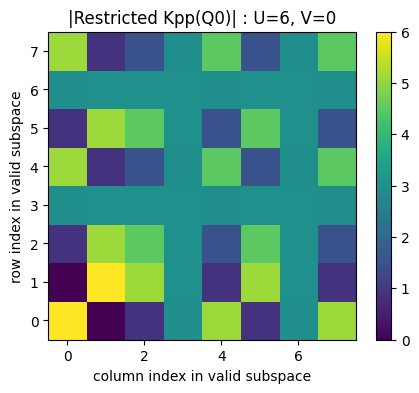

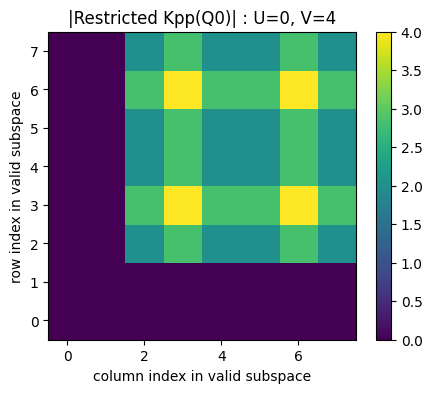

Top entries: U=6, V=0


,row,col,value,abs
0,0,0,6.00000+0.00000j,6.00000
1,1,1,6.00000+0.00000j,6.00000
2,0,7,5.12132+0.00000j,5.12132
3,0,4,5.12132+0.00000j,5.12132
4,1,2,5.12132+0.00000j,5.12132
5,1,5,5.12132+0.00000j,5.12132
6,2,1,5.12132+0.00000j,5.12132
7,4,0,5.12132+0.00000j,5.12132
8,5,1,5.12132+0.00000j,5.12132
9,7,0,5.12132+0.00000j,5.12132


Top entries: U=0, V=4


,row,col,value,abs
0,3,3,4.000000+0.000000j,4.000000
1,3,6,-4.000000+0.000000j,4.000000
2,6,3,-4.000000+0.000000j,4.000000
3,6,6,4.000000+0.000000j,4.000000
4,2,6,-2.828427+0.000000j,2.828427
5,2,3,2.828427+0.000000j,2.828427
6,3,5,-2.828427+0.000000j,2.828427
7,3,7,-2.828427+0.000000j,2.828427
8,5,3,-2.828427+0.000000j,2.828427
9,5,6,2.828427+0.000000j,2.828427


In [137]:
ker_pp_U6 = builder_U6.pp_block(
    Q0,
    incoming_pair=("up", "dn"),
    outgoing_pair=("up", "dn"),
)
ker_pp_V4 = builder_V4.pp_block(
    Q0,
    incoming_pair=("up", "dn"),
    outgoing_pair=("up", "dn"),
)

Kpp_U6 = np.asarray(ker_pp_U6.matrix)
Kpp_V4 = np.asarray(ker_pp_V4.matrix)

Kpp_U6_sub = Kpp_U6[np.ix_(pp_valid_ids, pp_valid_ids)]
Kpp_V4_sub = Kpp_V4[np.ix_(pp_valid_ids, pp_valid_ids)]

pp_stats_U6 = summarize_restricted_kernel(Kpp_U6_sub, title="Restricted Kpp(Q0) : U=6, V=0")
pp_stats_V4 = summarize_restricted_kernel(Kpp_V4_sub, title="Restricted Kpp(Q0) : U=0, V=4")

plot_kernel_abs(Kpp_U6_sub, title="|Restricted Kpp(Q0)| : U=6, V=0")
plot_kernel_abs(Kpp_V4_sub, title="|Restricted Kpp(Q0)| : U=0, V=4")

print("Top entries: U=6, V=0")
display(top_entries_df(Kpp_U6_sub, topn=20))

print("Top entries: U=0, V=4")
display(top_entries_df(Kpp_V4_sub, topn=20))

Restricted Kph(Q0) : U=6, V=0
  shape: (8, 8)
  max_abs: 6.0
  mean_abs: 3.0
  fro_norm: 26.832815729997478
  spec_radius_abs: 24.0
  max_real_eval: 24.0
Restricted Kph(Q0) : U=0, V=4
  shape: (8, 8)
  max_abs: 8.0
  mean_abs: 4.0
  fro_norm: 39.191835884530846
  spec_radius_abs: 32.00000000000001
  max_real_eval: 32.00000000000001


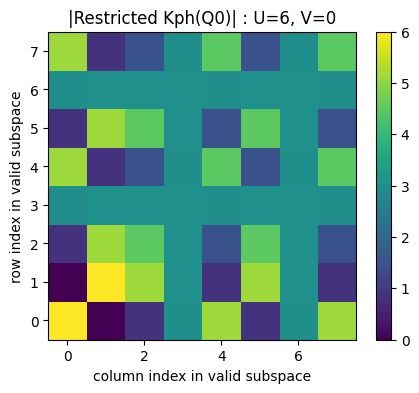

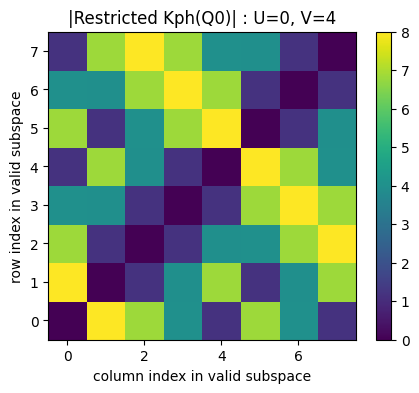

Top entries: U=6, V=0


,row,col,value,abs
0,0,0,6.00000+0.00000j,6.00000
1,1,1,6.00000+0.00000j,6.00000
2,0,7,5.12132+0.00000j,5.12132
3,0,4,5.12132+0.00000j,5.12132
4,1,2,5.12132+0.00000j,5.12132
5,1,5,5.12132+0.00000j,5.12132
6,2,1,5.12132+0.00000j,5.12132
7,4,0,5.12132+0.00000j,5.12132
8,5,1,5.12132+0.00000j,5.12132
9,7,0,5.12132+0.00000j,5.12132


Top entries: U=0, V=4


,row,col,value,abs
0,0,1,8.000000+0.000000j,8.000000
1,1,0,8.000000+0.000000j,8.000000
2,3,6,8.000000+0.000000j,8.000000
3,2,7,8.000000+0.000000j,8.000000
4,6,3,8.000000+0.000000j,8.000000
5,7,2,8.000000+0.000000j,8.000000
6,5,4,8.000000+0.000000j,8.000000
7,4,5,8.000000+0.000000j,8.000000
8,3,7,6.828427+0.000000j,6.828427
9,6,4,6.828427+0.000000j,6.828427


In [145]:
ker_ph_U6 = builder_U6.phd_block(
    Q0,
    incoming_bilinear=("up", "up"),
    outgoing_bilinear=("dn", "dn"),
)
ker_ph_V4 = builder_V4.phd_block(
    Q0,
    incoming_bilinear=("up", "up"),
    outgoing_bilinear=("up", "up"),
)

Kph_U6 = np.asarray(ker_ph_U6.matrix)
Kph_V4 = np.asarray(ker_ph_V4.matrix)

Kph_U6_sub = Kph_U6[np.ix_(ph_valid_ids, ph_valid_ids)]
Kph_V4_sub = Kph_V4[np.ix_(ph_valid_ids, ph_valid_ids)]

ph_stats_U6 = summarize_restricted_kernel(Kph_U6_sub, title="Restricted Kph(Q0) : U=6, V=0")
ph_stats_V4 = summarize_restricted_kernel(Kph_V4_sub, title="Restricted Kph(Q0) : U=0, V=4")

plot_kernel_abs(Kph_U6_sub, title="|Restricted Kph(Q0)| : U=6, V=0")
plot_kernel_abs(Kph_V4_sub, title="|Restricted Kph(Q0)| : U=0, V=4")

print("Top entries: U=6, V=0")
display(top_entries_df(Kph_U6_sub, topn=20))

print("Top entries: U=0, V=4")
display(top_entries_df(Kph_V4_sub, topn=20))

In [149]:
compare_df = pd.DataFrame([
    {
        "kernel": "Kpp(Q0)",
        "case": "U=6,V=0",
        **pp_stats_U6,
    },
    {
        "kernel": "Kpp(Q0)",
        "case": "U=0,V=4",
        **pp_stats_V4,
    },
    {
        "kernel": "Kph(Q0)",
        "case": "U=6,V=0",
        **ph_stats_U6,
    },
    {
        "kernel": "Kph(Q0)",
        "case": "U=0,V=4",
        **ph_stats_V4,
    },
])

display(compare_df)

,kernel,case,shape,max_abs,mean_abs,fro_norm,spec_radius_abs,max_real_eval
0,Kpp(Q0),"U=6,V=0","(8, 8)",6.0,3.000000,26.832816,24.0,2.400000e+01
1,Kpp(Q0),"U=0,V=4","(8, 8)",4.0,1.457107,16.000000,16.0,1.600000e+01
2,Kph(Q0),"U=6,V=0","(8, 8)",3.0,1.092830,12.000000,12.0,1.200000e+01
3,Kph(Q0),"U=0,V=4","(8, 8)",8.0,4.000000,39.191836,32.0,6.198482e-15


## Bare-level vertex decomposition at $Q=0$ and $Q=M$

We analyze the **bare interaction vertex $\Gamma$** by directly constructing
channel kernels (pp and ph) restricted to the **FS patch subspace**, without RG flow.

We compare two limits:
- Onsite interaction: $U=6, V=0$
- Nearest-neighbor interaction: $U=0, V=4$

All kernels are evaluated on the **valid nesting subspace** for each $Q$.

---

### 1. Sublattice interference of $U$

We observe a clear suppression of finite-$Q$ scattering for onsite interaction:

- **pp channel:**
  - $K_{pp}(Q=0) > K_{pp}(Q=M)$

- **ph (spin-longitudinal) channel:**
  - $K_{ph}(Q=0) > K_{ph}(Q=M)$

This indicates that:
> Onsite $U$ favors **$Q=0$ processes**, while **finite-$Q$ (nesting) channels are suppressed**.

This is consistent with the **sublattice interference mechanism** discussed in PRL:
destructive interference in the Bloch form factors reduces scattering at $Q=M$.

---

### 2. Behavior of $V$ (nearest-neighbor interaction)

For $V=4$, we find:

- **ph channel:**
  - $K_{ph}(Q=0) \approx K_{ph}(Q=M)$
  - No clear dominance of $Q=M$ over $Q=0$

- **pp channel:**
  - $K_{pp}(Q=M) > K_{pp}(Q=0)$

This suggests:

> Nearest-neighbor interaction $V$ does **not suffer from sublattice interference**,
> and supports **finite-$Q$ scattering strongly**.

However:

> At the **bare vertex level**, $V$ does **not yet clearly select $Q=M$ over $Q=0$**
> in the particle-hole channel.

---

### 3. Key takeaway

- Sublattice interference of $U$ is already visible at the **bare vertex level**.
- $V$ activates finite-$Q$ channels, but:
  - does **not strongly prefer $Q=M$ over $Q=0$** at this stage.
- The final selection of ordering wavevector (e.g. $Q=M$ vs $Q=0$)
  must therefore come from:
  - loop (bubble) effects
  - channel competition
  - RG flow amplification

---

### 4. Interpretation

At the bare level:

- $U$ → biases toward $Q=0$ (FM tendency)
- $V$ → enhances both $Q=0$ and $Q=M$ channels

Thus:

> The emergence of $Q=M$ instabilities in the $V$-dominated regime
> is **not purely encoded in the bare vertex**, but requires
> **RG flow and collective enhancement**.

---

# One Loop Diagram for QM1

In [300]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolver, BareVertexFromInteraction
from channels import FullVertexChannelBuilder
from frg_kernel import canonicalize_q_for_patchsets

PATCHSETS = patchsets
MODEL = model

T_START = 30.0
T_STOP = 2.0
N_STEPS = 300
NFREQ = 30
MAX_STEPS_TO_RECORD = 300

ref_spin = "up"
ps_ref = PATCHSETS[ref_spin]
b1 = np.asarray(ps_ref.b1, dtype=float)

Q0 = np.zeros(2, dtype=float)
QM1 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b1)

Q_DICT = {
    "Q0": Q0,
    "QM1": QM1,
}

print("Q0  =", np.array2string(Q0, precision=10))
print("QM1 =", np.array2string(QM1, precision=10))
print("Npatch =", ps_ref.Npatch)

Q0  = [0. 0.]
QM1 = [0.           1.8137993642]
Npatch = 21


In [304]:
solver_U6, df_strength_U6, df_steps_U6 = trace_early_flow_physical(
    U=6.0, V=0.0,
    case_label="U6_V0",
)

solver_V4, df_strength_V4, df_steps_V4 = trace_early_flow_physical(
    U=4.0, V=4.0,
    case_label="U0_V4",
)

df_strength = pd.concat([df_strength_U6, df_strength_V4], ignore_index=True)
df_steps = pd.concat([df_steps_U6, df_steps_V4], ignore_index=True)

display(df_steps)
display(df_strength.head(20))

,case,step,T,dT,channel_norm,rhs_norm,accepted_substeps,max_rel_update,instability,instability_reason,terminated_early,termination_reason
0,U6_V0,1,29.729516,-0.270484,6.000000,0.067219,1,0.003030,False,NaN,False,None
1,U6_V0,2,29.461471,-0.268045,6.000447,0.068952,1,0.003080,False,NaN,False,None
2,U6_V0,3,29.195842,-0.265629,6.001355,0.070739,1,0.003131,False,NaN,False,None
3,U6_V0,4,28.932609,-0.263234,6.002737,0.072584,1,0.003184,False,NaN,False,None
4,U6_V0,5,28.671748,-0.260860,6.004607,0.074487,1,0.003237,False,NaN,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...
130,U0_V4,24,24.139000,-0.219621,61.935893,69.327370,3,0.108475,False,NaN,False,None
131,U0_V4,25,23.921360,-0.217640,89.210059,125.725335,3,0.147265,False,NaN,False,None
132,U0_V4,26,23.705682,-0.215678,147.268883,269.709899,5,0.130413,False,NaN,False,None
133,U0_V4,27,23.491948,-0.213734,309.280085,758.884350,8,0.137673,False,NaN,False,None


,case,step,T,Q_tag,kernel,valid_size_pp,valid_size_ph,shape,max_abs,mean_abs,fro_norm,spec_radius_abs,max_real_eval
0,U6_V0,0,30.000000,Q0,pp_singlet,21,21,"(21, 21)",12.000000,4.000000,108.000000,84.000000,8.400000e+01
1,U6_V0,0,30.000000,Q0,pp_triplet,21,21,"(21, 21)",0.000000,0.000000,0.000000,0.000000,0.000000e+00
2,U6_V0,0,30.000000,Q0,ph_charge,21,21,"(21, 21)",6.000000,2.000000,54.000000,42.000000,4.200000e+01
3,U6_V0,0,30.000000,Q0,ph_spin,21,21,"(21, 21)",6.000000,2.000000,54.000000,42.000000,6.627139e-16
4,U6_V0,0,30.000000,QM1,pp_singlet,8,8,"(8, 8)",6.000000,2.185660,24.000000,24.000000,2.400000e+01
5,U6_V0,0,30.000000,QM1,pp_triplet,8,8,"(8, 8)",0.000000,0.000000,0.000000,0.000000,0.000000e+00
6,U6_V0,0,30.000000,QM1,ph_charge,8,8,"(8, 8)",3.000000,1.092830,12.000000,12.000000,1.200000e+01
7,U6_V0,0,30.000000,QM1,ph_spin,8,8,"(8, 8)",3.000000,1.092830,12.000000,12.000000,2.394589e-16
8,U6_V0,1,29.729516,Q0,pp_singlet,21,21,"(21, 21)",12.000000,4.020142,108.405911,84.422991,8.442299e+01
9,U6_V0,1,29.729516,Q0,pp_triplet,21,21,"(21, 21)",0.017129,0.001486,0.092872,0.036273,3.627269e-02


In [358]:
df_strength['spec_radius_abs'][:df_strength['spec_radius_abs'].shape[0]-10].shape

(1086,)

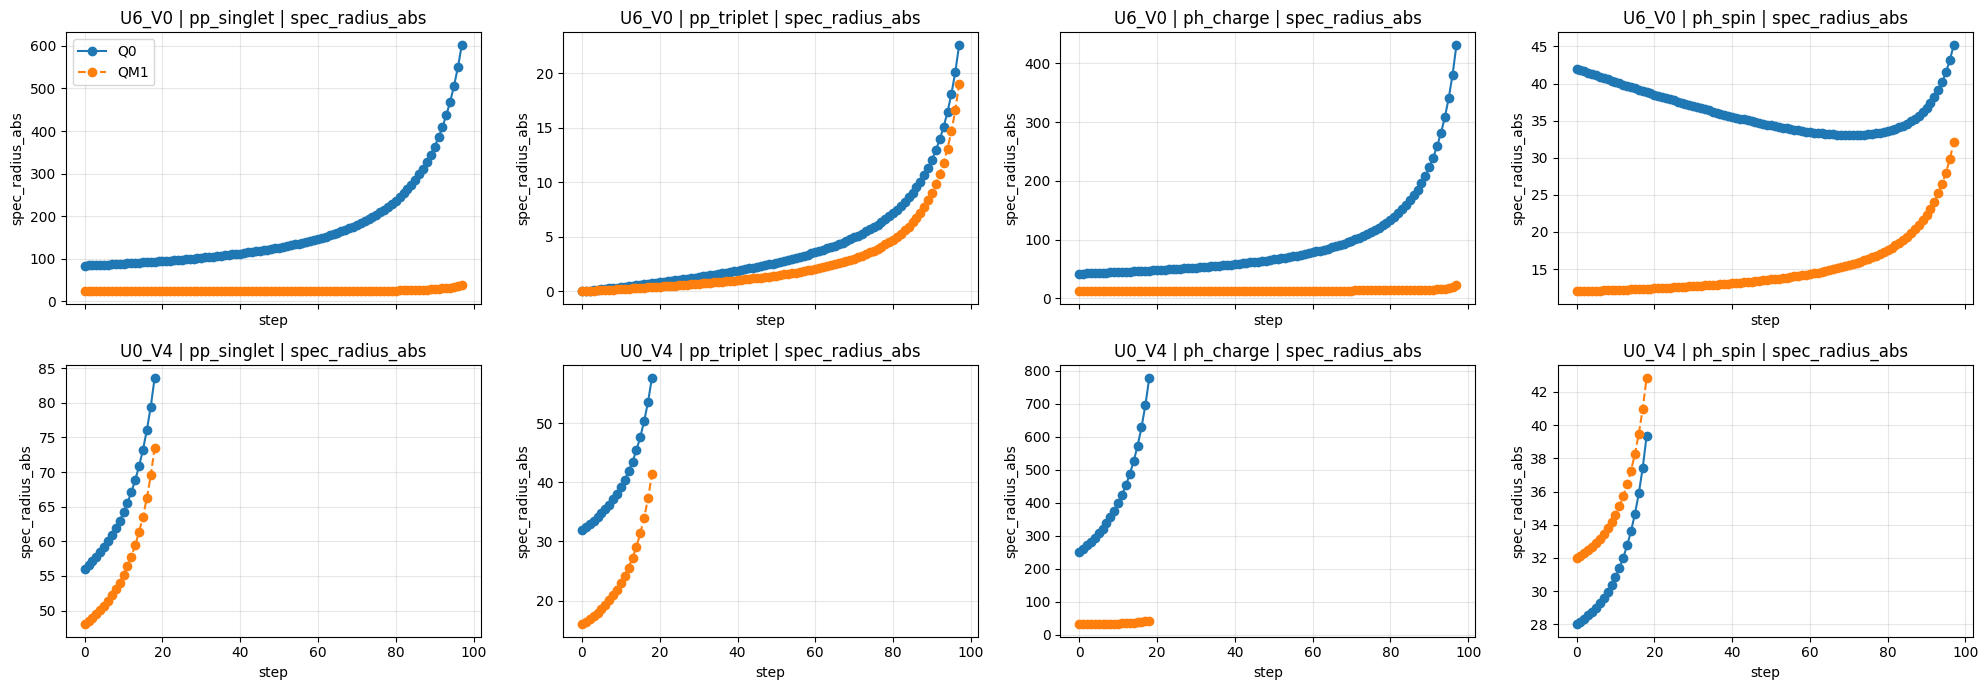

In [426]:
plot_strength_vs_step(df_strength, metric="spec_radius_abs",cutoff=10)
# plot_strength_vs_step(df_strength, metric="fro_norm")
# plot_strength_vs_step(df_strength, metric="max_abs")

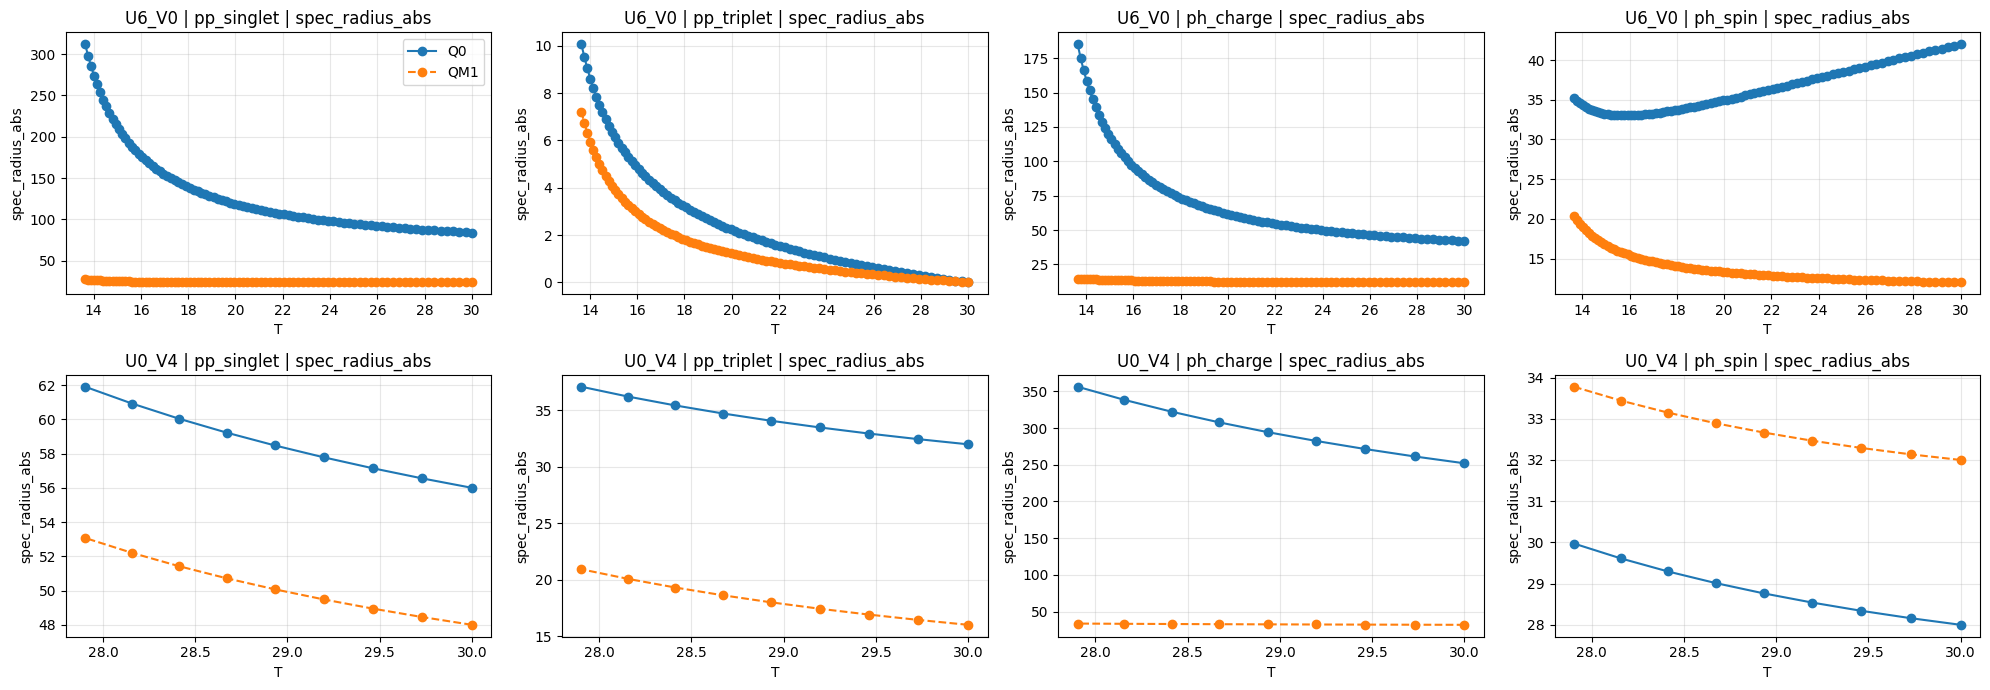

In [454]:
plot_strength_vs_T(df_strength, metric="spec_radius_abs",cutoff=20)
# plot_strength_vs_T(df_strength, metric="fro_norm")
# plot_strength_vs_T(df_strength, metric="max_abs")

In [320]:
summary_spec, summary_fro = make_summary_tables(df_strength)
display(summary_spec)
display(summary_fro)

kernel                    ph_charge                   ph_spin               \
Q_tag                            Q0          QM1           Q0          QM1   
case  step T                                                                 
U0_V4 0    30.000000     252.000000    32.000000    28.000000    32.000000   
      1    29.729516     261.314468    32.128451    28.160801    32.136490   
      2    29.461471     271.424614    32.274908    28.339809    32.291207   
      3    29.195842     282.434864    32.441808    28.539491    32.466593   
      4    28.932609     294.468538    32.632035    28.762761    32.665533   
...                             ...          ...          ...          ...   
U6_V0 103  11.802648    1709.048078    68.797446    89.385260    78.195689   
      104  11.696234    2801.774407   102.128946   121.841151   111.259146   
      105  11.590779    5766.293260   184.388360   202.793598   193.116915   
      106  11.486275   18440.942907   508.278418   524.248558   516.276570   
      107  11.382713  149272.142252  3696.371138  3716.451851  3714.295774   

kernel                  pp_singlet                pp_triplet               
Q_tag                           Q0          QM1           Q0          QM1  
case  step T                                                               
U0_V4 0    30.000000     56.000000    48.000000    32.000000    16.000000  
      1    29.729516     56.552879    48.455079    32.458594    16.434283  
      2    29.461471     57.145593    48.948435    32.955573    16.907322  
      3    29.195842     57.783247    49.485098    33.495994    17.424209  
      4    28.932609     58.471865    50.071012    34.085830    17.990955  
...                            ...          ...          ...          ...  
U6_V0 103  11.802648   1390.795036    97.319739    84.828248    80.750766  
      104  11.696234   1764.357645   149.634892   137.946393   133.808486  
      105  11.590779   2407.809416   292.830389   282.269583   278.107275  
      106  11.486275   3876.236767   908.913525   900.434553   896.356380  
      107  11.382713  11868.340086  7292.316024  7289.582206  7286.065331  

[137 rows x 8 columns]

kernel                    ph_charge                     ph_spin                \
Q_tag                            Q0           QM1            Q0           QM1   
case  step T                                                                    
U0_V4 0    30.000000     262.449995     43.081318     45.431267     36.660606   
      1    29.729516     271.407410     43.339708     45.929684     36.933268   
      2    29.461471     281.170861     43.635862     46.495356     37.243085   
      3    29.195842     291.845522     43.975624     47.138946     37.595956   
      4    28.932609     303.555575     44.366011     47.873228     37.998982   
...                             ...           ...           ...           ...   
U6_V0 103  11.802648    1724.435041    118.354447    255.881249    155.261155   
      104  11.696234    2822.422340    184.791391    377.785686    233.825935   
      105  11.590779    5802.881537    372.104972    702.259888    439.231207   
      106  11.486275   18551.611318   1211.867425   2094.059618   1304.872649   
      107  11.382713  150174.354809  10094.051691  16548.094992  10216.047105   

kernel                  pp_singlet                  pp_triplet                
Q_tag                           Q0           QM1            Q0           QM1  
case  step T                                                                  
U0_V4 0    30.000000     72.000000     61.967734     55.425626     39.191836  
      1    29.729516     72.866909     62.559232     56.215592     39.514743  
      2    29.461471     73.832441     63.211244     57.100495     39.881289  
      3    29.195842     74.912041     63.933040     58.094749     40.298826  
      4    28.932609     76.124245     64.735755     59.215552     40.776235  
...                            ...           ...           ...           ...  
U6_V0 103  11.802648   1421.750982    181.881347    248.710273    136.574453  
      104  11.696234   1822.433771    298.757171    407.505662    227.434415  
      105  11.590779   2574.225761    618.078772    839.529794    474.749006  
      106  11.486275   4840.460011   1989.166973   2691.345383   1534.803813  
      107  11.382713  26529.309086  16166.930436  21833.868852  12490.696428  

[137 rows x 8 columns]

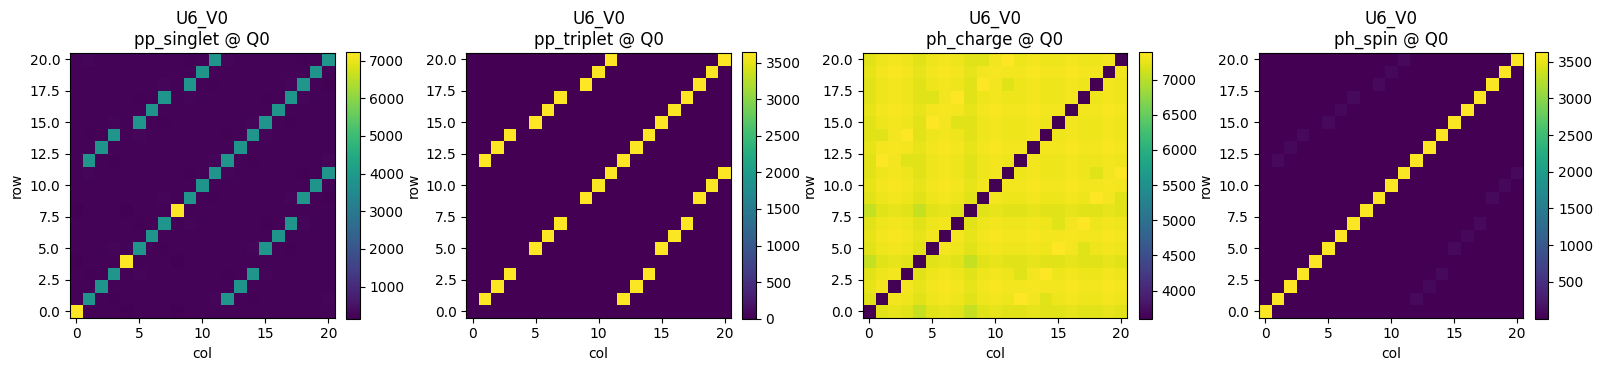

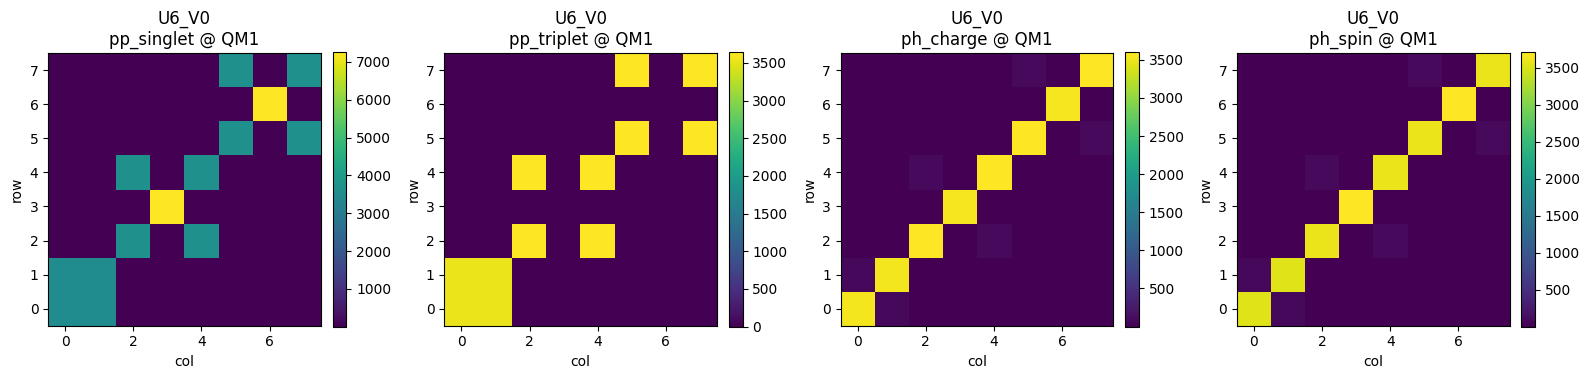

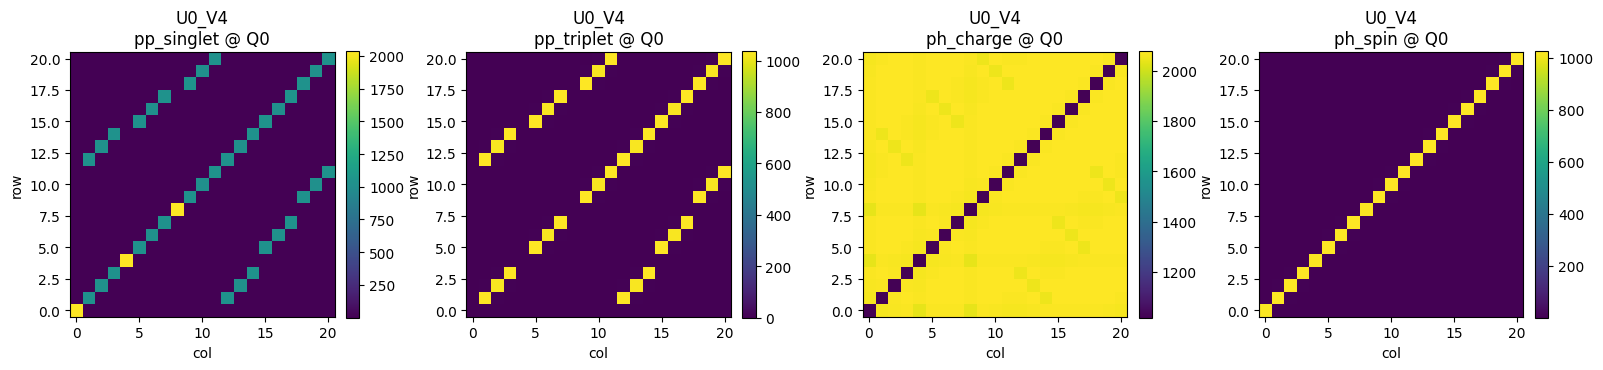

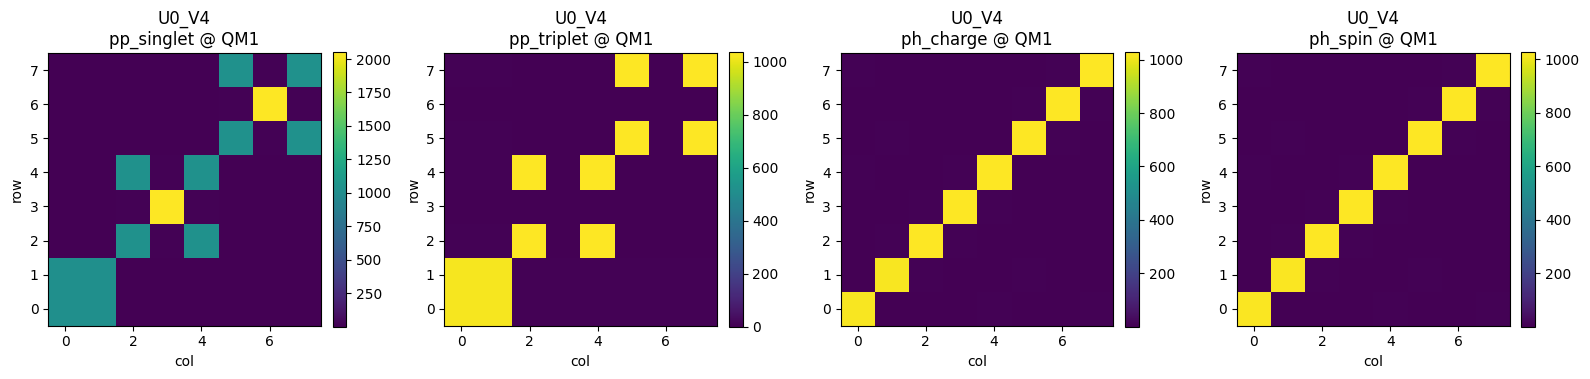

In [322]:
plot_last_step_heatmaps(solver_U6, case_label="U6_V0")
plot_last_step_heatmaps(solver_V4, case_label="U0_V4")

# Full Patch

In [710]:
solver_U6, df_mother_U6, df_steps_U6 = trace_early_flow_mother(
    U=6.0, V=0.0,
    case_label="U6_V0",
)

solver_U3V3, df_mother_U3V3, df_steps_U3V3 = trace_early_flow_mother(
    U=0.0, V=8,
    case_label="U3_V3",
)

df_mother = pd.concat([df_mother_U6, df_mother_U3V3], ignore_index=True)
df_steps = pd.concat([df_steps_U6, df_steps_U3V3], ignore_index=True)

display(df_steps)
display(df_mother.head(20))

TypeError: 'MotherChannelKernel' object is not subscriptable

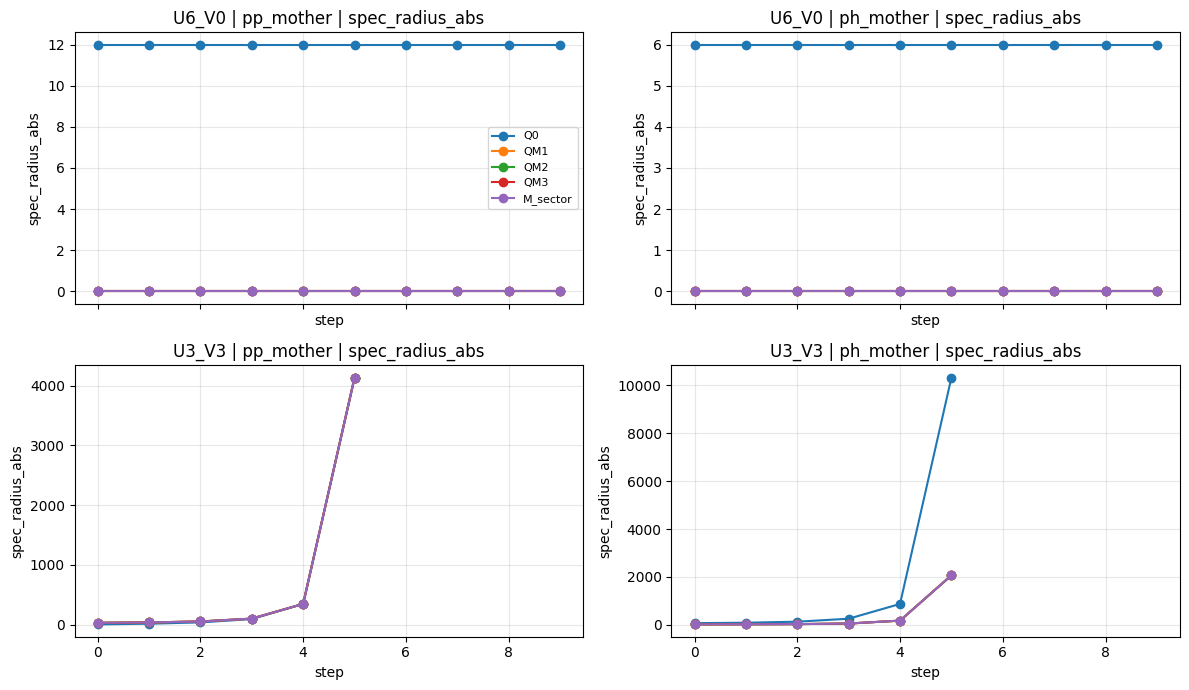

In [712]:
plot_mother_strength_vs_step(df_mother, metric="spec_radius_abs")
# plot_mother_strength_vs_step(df_mother, metric="fro_norm")
# plot_mother_strength_vs_step(df_mother, metric="max_abs")

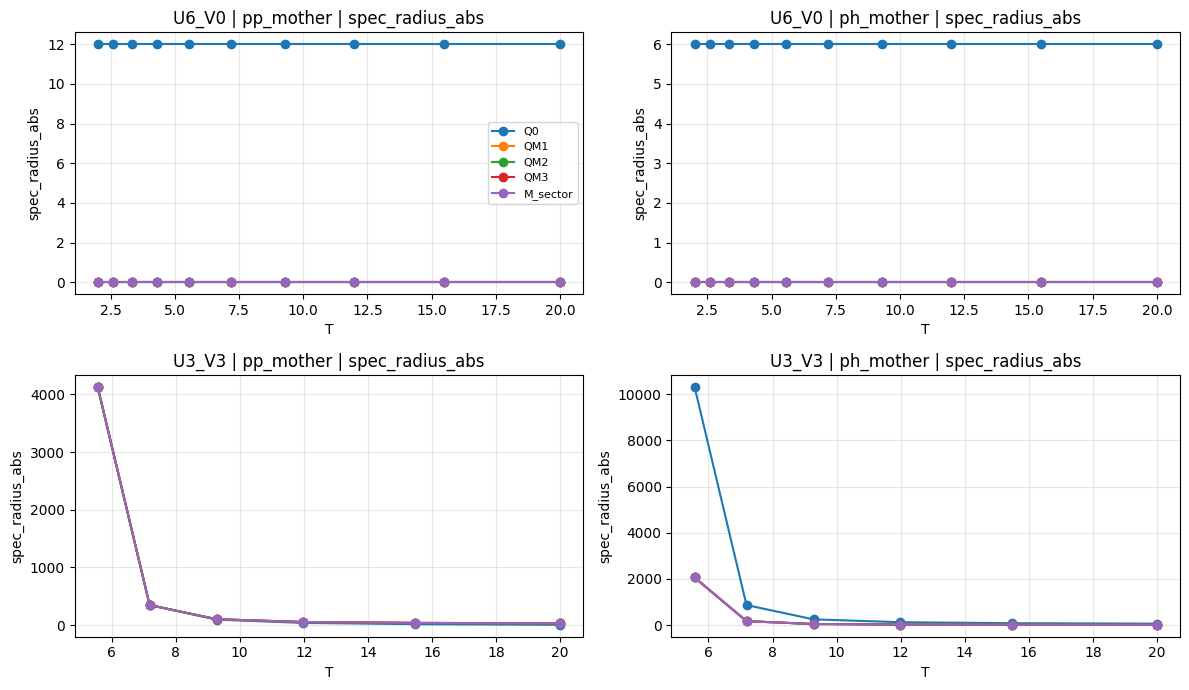

In [714]:
plot_mother_strength_vs_T(df_mother, metric="spec_radius_abs")
# plot_mother_strength_vs_T(df_mother, metric="fro_norm")
# plot_mother_strength_vs_T(df_mother, metric="max_abs")

In [716]:
# summary_spec, summary_fro = make_mother_summary_tables(df_mother)
# display(summary_spec)
# display(summary_fro)
# display(final_leading_mode_table(solver_U6, case_label="U6_V0"))
# display(final_leading_mode_table(solver_U3V3, case_label="U3_V3"))

TypeError: 'MotherChannelKernel' object is not subscriptable

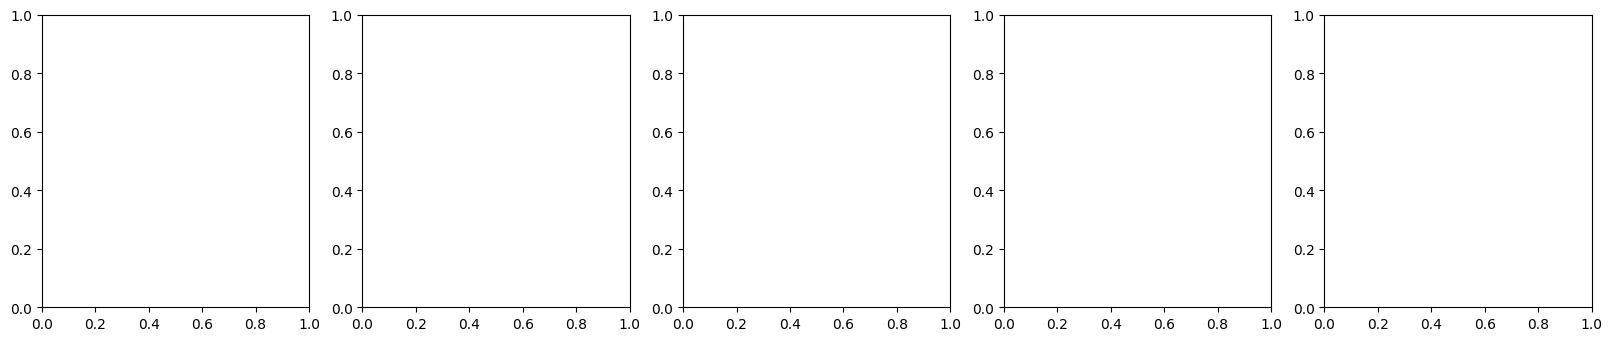

In [718]:
plot_last_step_mother_heatmaps(solver_U6, case_label="U6_V0")
plot_last_step_mother_heatmaps(solver_U3V3, case_label="U3_V3")

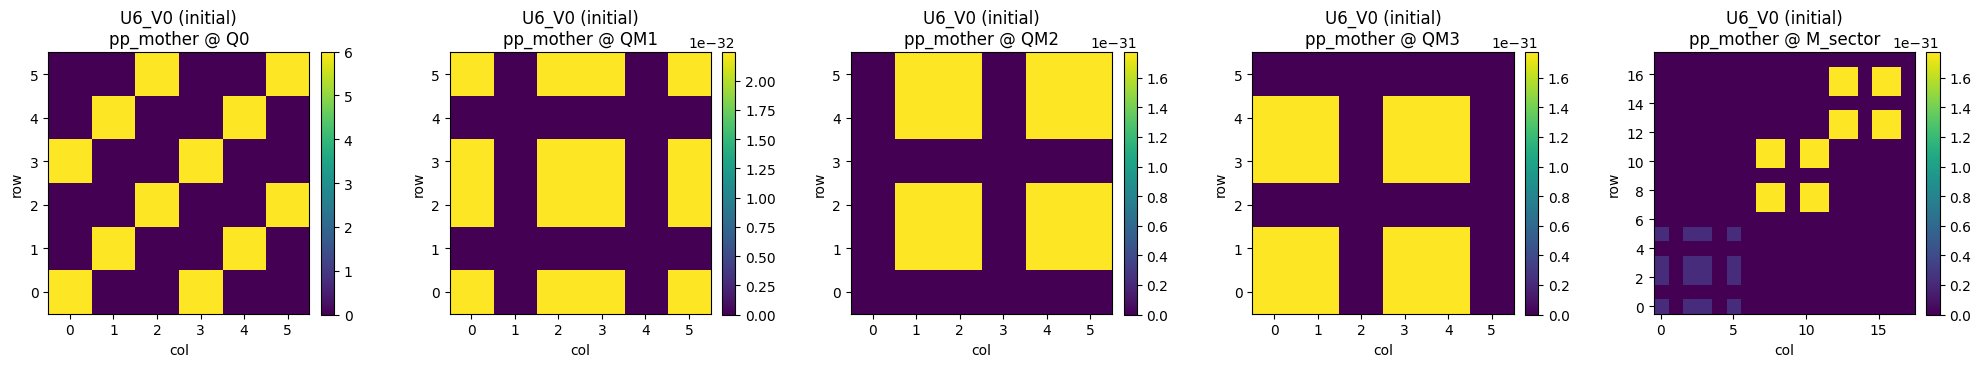

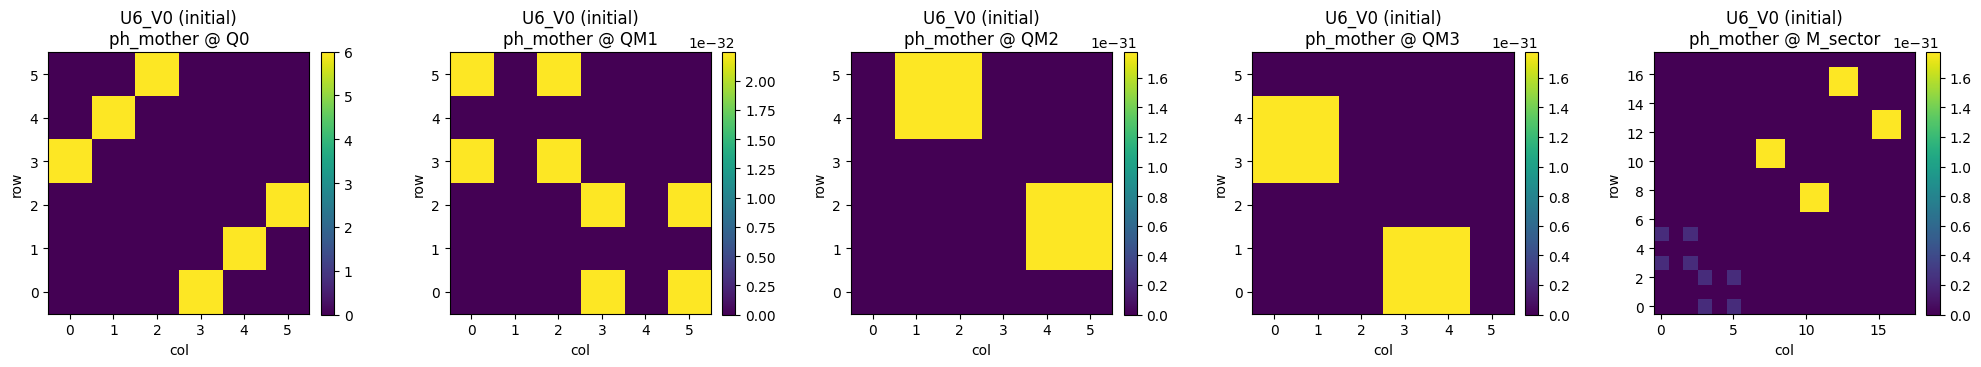

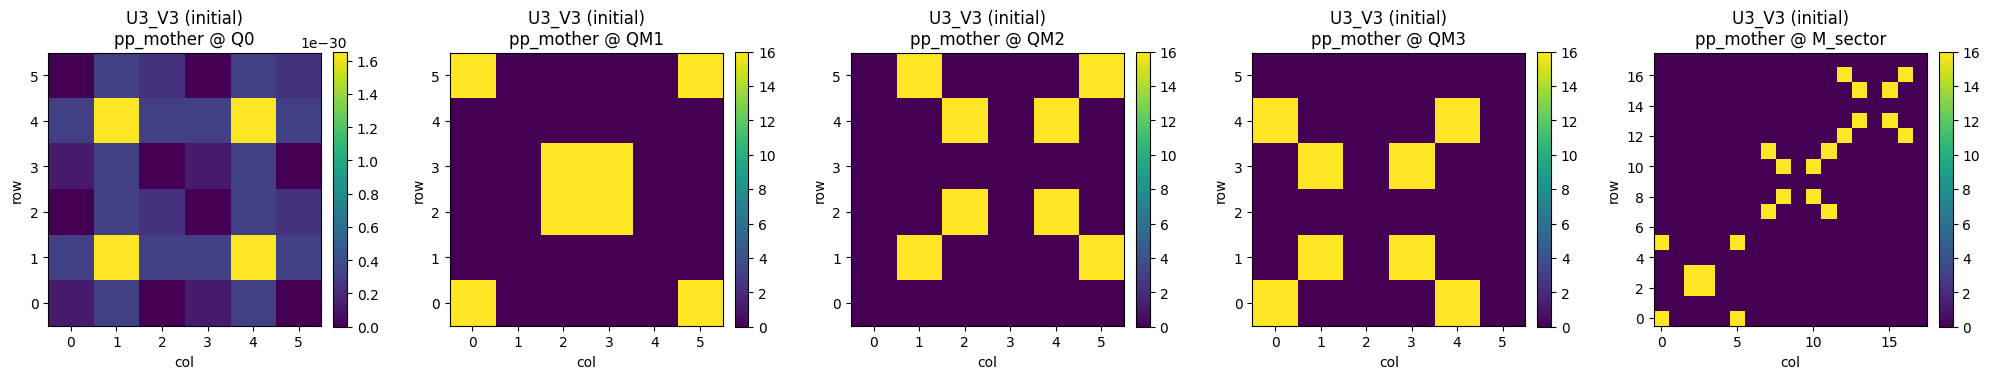

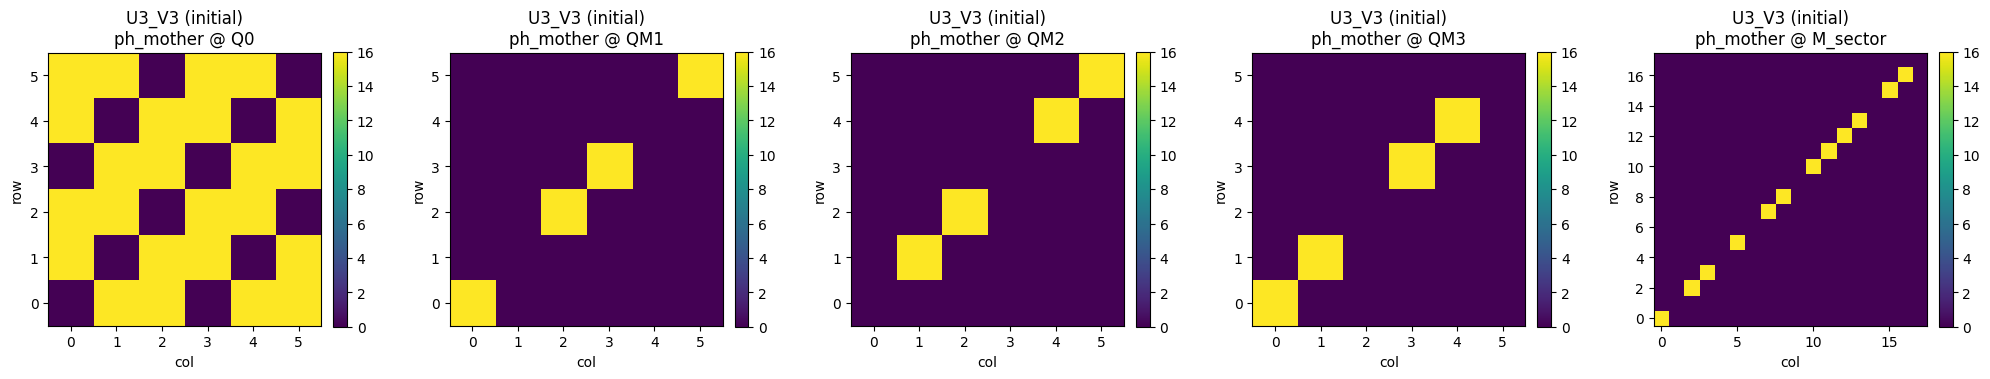

In [575]:
solver_U6 = build_solver(PATCHSETS, U=6.0, V=0.0)
solver_U3V3 = build_solver(PATCHSETS, U=0.0, V=8.0)

kernels_U6 = initial_mother_kernels(solver_U6)
kernels_U3V3 = initial_mother_kernels(solver_U3V3)
plot_initial_mother_heatmaps(kernels_U6, case_label="U6_V0 (initial)")
plot_initial_mother_heatmaps(kernels_U3V3, case_label="U3_V3 (initial)")


================== ACTIVE SUBMATRICES @ Q=0 ==================

phd_uu_to_uu
row_spins = ('up', 'up')  col_spins = ('up', 'up')
active rows = [0 1 2]
active cols = [0 1 2]
initial active matrix:
[[ 0. 16. 16.]
 [16.  0. 16.]
 [16. 16.  0.]]
final active matrix:
[[   0.    2065.566 2065.566]
 [2065.566    0.    2065.566]
 [2065.566 2065.566    0.   ]]
phd_uu_to_dd
row_spins = ('dn', 'dn')  col_spins = ('up', 'up')
active rows = [0 1 2]
active cols = [0 1 2]
initial active matrix:
[[ 3. 16. 16.]
 [16.  3. 16.]
 [16. 16.  3.]]
final active matrix:
[[2061.589 2065.566 2065.566]
 [2065.566 2061.589 2065.566]
 [2065.566 2065.566 2061.589]]
phd_dd_to_uu
row_spins = ('up', 'up')  col_spins = ('dn', 'dn')
active rows = [0 1 2]
active cols = [0 1 2]
initial active matrix:
[[ 3. 16. 16.]
 [16.  3. 16.]
 [16. 16.  3.]]
final active matrix:
[[2061.589 2065.566 2065.566]
 [2065.566 2061.589 2065.566]
 [2065.566 2065.566 2061.589]]
phd_dd_to_dd
row_spins = ('dn', 'dn')  col_spins = ('dn', 'dn')
acti

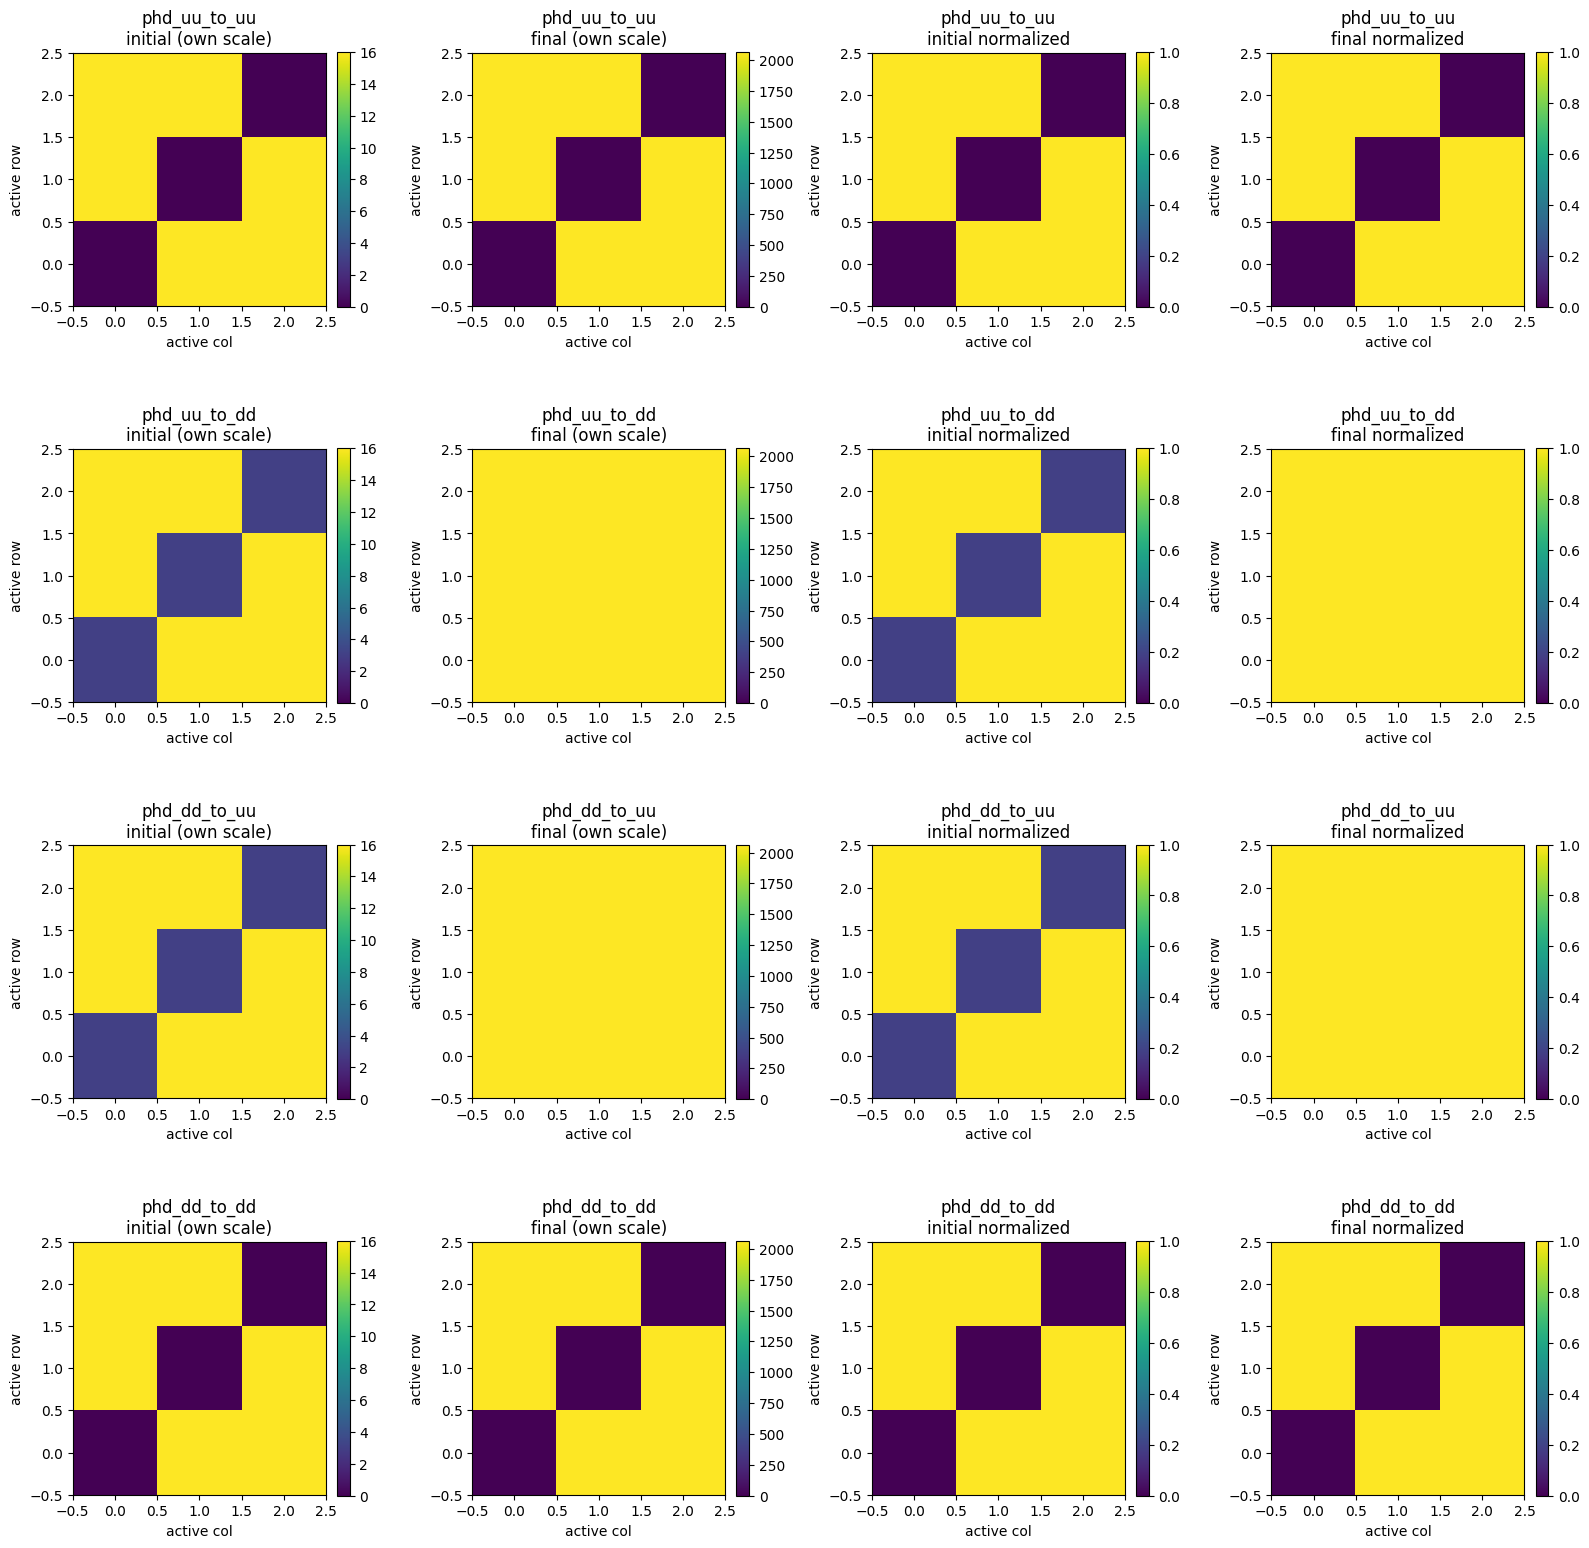

In [708]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import channels
importlib.reload(channels)
from channels import FullVertexChannelBuilder

# ============================================================
# choose solver
# ============================================================
if "solver_U3V3" in globals():
    solver_case = solver_U3V3
elif "solver_u3v3" in globals():
    solver_case = solver_u3v3
else:
    raise ValueError("Cannot find solver_U3V3 (or solver_u3v3).")

Q0 = np.array([0.0, 0.0], dtype=float)

builder_init = FullVertexChannelBuilder.from_solver(solver_case.bare_gamma, solver_case)
builder_final = FullVertexChannelBuilder.from_solver(solver_case.current_gamma_accessor(), solver_case)

raw_init = builder_init.build_raw_block_dict(Q0)
raw_final = builder_final.build_raw_block_dict(Q0)

ph_keys = [
    "phd_uu_to_uu",
    "phd_uu_to_dd",
    "phd_dd_to_uu",
    "phd_dd_to_dd",
]

def active_patch_indices(kernel):
    rp = np.asarray(kernel.row_partner_patches, dtype=int)
    cp = np.asarray(kernel.col_partner_patches, dtype=int)
    rows = np.where(rp >= 0)[0]
    cols = np.where(cp >= 0)[0]
    return rows, cols

def active_submatrix(kernel):
    M = np.asarray(kernel.matrix)
    rows, cols = active_patch_indices(kernel)
    return M[np.ix_(rows, cols)], rows, cols

def normalize_abs(M):
    Mabs = np.abs(M)
    vmax = np.max(Mabs) if Mabs.size else 1.0
    if vmax < 1e-14:
        vmax = 1.0
    return Mabs / vmax

print("\n================== ACTIVE SUBMATRICES @ Q=0 ==================\n")
for k in ph_keys:
    M0, rows0, cols0 = active_submatrix(raw_init[k])
    M1, rows1, cols1 = active_submatrix(raw_final[k])

    print("=" * 90)
    print(k)
    print("row_spins =", raw_init[k].row_spins, " col_spins =", raw_init[k].col_spins)
    print("active rows =", rows0)
    print("active cols =", cols0)
    print("initial active matrix:")
    print(np.array_str(np.abs(M0), precision=3, suppress_small=False))
    print("final active matrix:")
    print(np.array_str(np.abs(M1), precision=3, suppress_small=False))

fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i, k in enumerate(ph_keys):
    M0, rows0, cols0 = active_submatrix(raw_init[k])
    M1, rows1, cols1 = active_submatrix(raw_final[k])

    M0abs = np.abs(M0)
    M1abs = np.abs(M1)

    vmax0 = np.max(M0abs) if M0abs.size else 1.0
    vmax1 = np.max(M1abs) if M1abs.size else 1.0
    if vmax0 < 1e-14:
        vmax0 = 1.0
    if vmax1 < 1e-14:
        vmax1 = 1.0

    # initial own scale
    im = axes[i, 0].imshow(M0abs, origin="lower", vmin=0.0, vmax=vmax0)
    axes[i, 0].set_title(f"{k}\ninitial (own scale)")
    axes[i, 0].set_xlabel("active col")
    axes[i, 0].set_ylabel("active row")
    plt.colorbar(im, ax=axes[i, 0], fraction=0.046, pad=0.04)

    # final own scale
    im = axes[i, 1].imshow(M1abs, origin="lower", vmin=0.0, vmax=vmax1)
    axes[i, 1].set_title(f"{k}\nfinal (own scale)")
    axes[i, 1].set_xlabel("active col")
    axes[i, 1].set_ylabel("active row")
    plt.colorbar(im, ax=axes[i, 1], fraction=0.046, pad=0.04)

    # initial normalized
    im = axes[i, 2].imshow(normalize_abs(M0), origin="lower", vmin=0.0, vmax=1.0)
    axes[i, 2].set_title(f"{k}\ninitial normalized")
    axes[i, 2].set_xlabel("active col")
    axes[i, 2].set_ylabel("active row")
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    # final normalized
    im = axes[i, 3].imshow(normalize_abs(M1), origin="lower", vmin=0.0, vmax=1.0)
    axes[i, 3].set_title(f"{k}\nfinal normalized")
    axes[i, 3].set_xlabel("active col")
    axes[i, 3].set_ylabel("active row")
    plt.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Using Q = [0.         1.81379936]

Available raw keys:
   pp_ud_to_ud
   pp_ud_to_du
   pp_du_to_ud
   pp_du_to_du
   phd_uu_to_uu
   phd_uu_to_dd
   phd_dd_to_uu
   phd_dd_to_dd
   pp_uu_to_uu
   phc_uu
   pp_dd_to_dd
   phc_dd


############################
PP raw blocks @ Q = QM1
############################

pp_ud_to_ud
kernel.name         = pp_raw
shape               = (24, 24)
row_spins           = ('up', 'dn')
col_spins           = ('up', 'dn')
row_patches         = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
col_patches         = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
row_partner_patches = [ 8 -1 -1 -1 -1 -1 -1 -1  0 11 10  9  8 -1 -1 -1 -1 -1 -1 -1  0 23 22 21]
col_partner_patches = [ 8 -1 -1 -1 -1 -1 -1 -1  0 11 10  9  8 -1 -1 -1 -1 -1 -1 -1  0 23 22 21]
hermitian_residual  = 4.440892098500626e-16
nonzero entries (i, j, value):
  (9, 9) : (1.5000000000000004-4.930380657631324e-32j)
  (9, 10) : (2.121320343559643

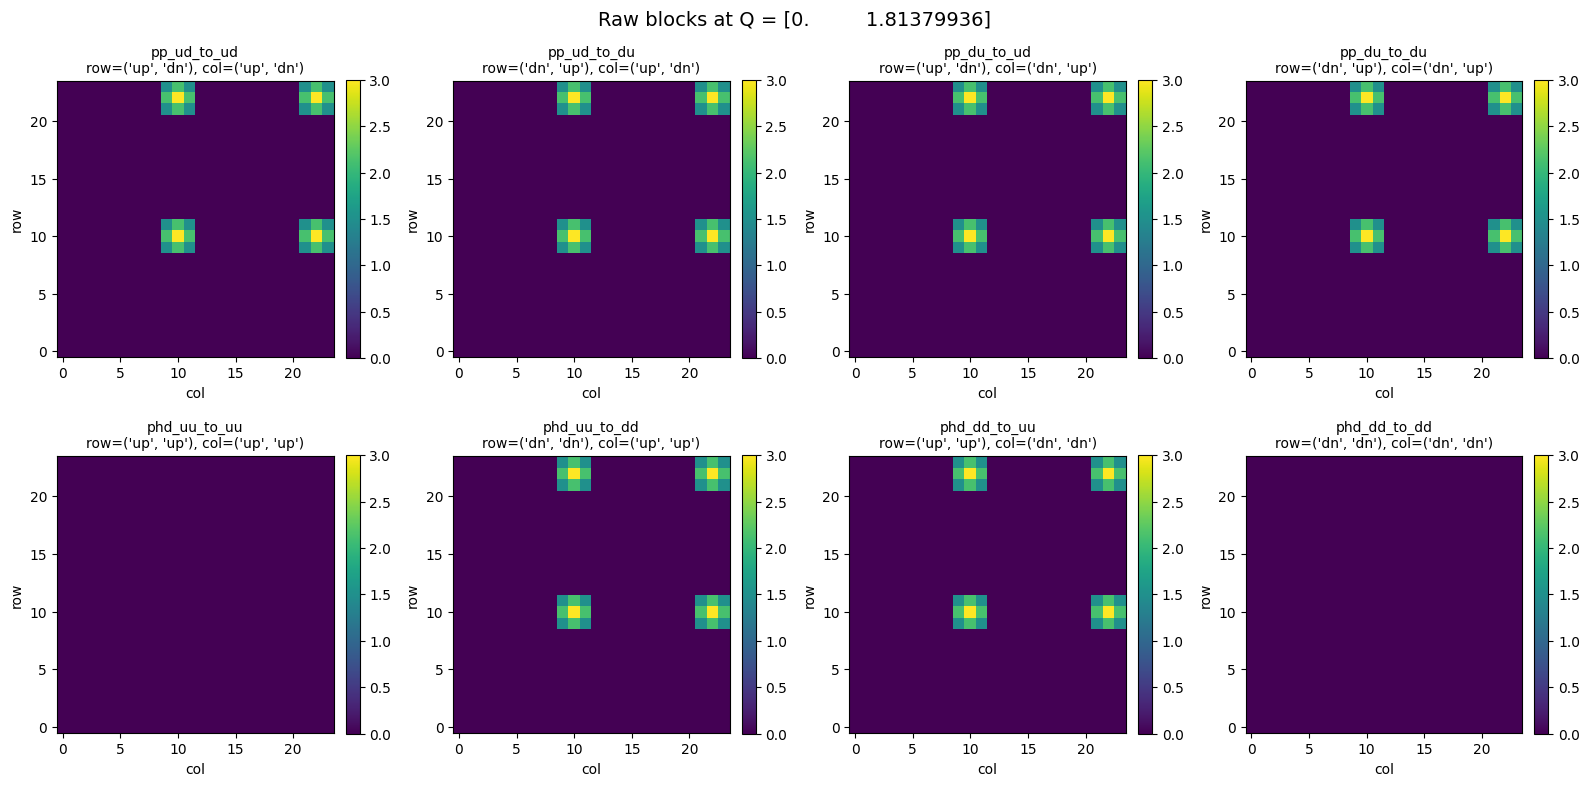



############################
Pairwise raw-block comparison
############################

pp_ud_to_ud vs pp_du_to_du: max|A-B| = 0.0
pp_ud_to_du vs pp_du_to_ud: max|A-B| = 0.0
phd_uu_to_uu vs phd_dd_to_dd: max|A-B| = 0.0
phd_uu_to_dd vs phd_dd_to_uu: max|A-B| = 0.0


############################
Row/col semantic check
############################

phd_uu_to_uu    | row_spins=('up', 'up') | col_spins=('up', 'up')
phd_uu_to_dd    | row_spins=('dn', 'dn') | col_spins=('up', 'up')
phd_dd_to_uu    | row_spins=('up', 'up') | col_spins=('dn', 'dn')
phd_dd_to_dd    | row_spins=('dn', 'dn') | col_spins=('dn', 'dn')
pp_ud_to_ud     | row_spins=('up', 'dn') | col_spins=('up', 'dn')
pp_ud_to_du     | row_spins=('dn', 'up') | col_spins=('up', 'dn')
pp_du_to_ud     | row_spins=('up', 'dn') | col_spins=('dn', 'up')
pp_du_to_du     | row_spins=('dn', 'up') | col_spins=('dn', 'up')


In [615]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

# ============================================================
# 0. reload local modules (important when you edited files)
# ============================================================
import channels
import frg_flow
import frg_kernel

importlib.reload(channels)
importlib.reload(frg_flow)
importlib.reload(frg_kernel)

from channels import FullVertexChannelBuilder

# ============================================================
# 1. locate solver
# ============================================================
if "solver" not in globals():
    raise ValueError("solver not found in notebook globals(). Please make sure your solver object exists.")

# ============================================================
# 2. locate Q = M1 / QM1
# ============================================================
def _pick_QM1():
    g = globals()
    if "QM1" in g:
        return np.asarray(g["QM1"], dtype=float)
    if "M1" in g:
        return np.asarray(g["M1"], dtype=float)

    # try from solver grids if available
    if hasattr(solver, "phd_grid"):
        qs = [np.asarray(q, dtype=float) for q in solver.phd_grid.q_list]
        nonzero = [q for q in qs if np.linalg.norm(q) > 1e-10]
        if len(nonzero) == 0:
            raise ValueError("Could not infer QM1: solver.phd_grid.q_list has no nonzero Q.")
        print("[warn] QM1/M1 not explicitly found; using first nonzero Q from solver.phd_grid.q_list:")
        print(nonzero[0])
        return nonzero[0]

    raise ValueError("Could not find QM1 or M1 in globals(), and solver.phd_grid is unavailable.")

Q = _pick_QM1()
print("Using Q =", Q)

# ============================================================
# 3. build channel builder from CURRENT solver vertex
#    This uses the currently stored vertex state in solver.
#    For the initial bare state, run this before flow,
#    or rebuild solver freshly.
# ============================================================
gamma_accessor = solver.current_gamma_accessor()
builder = FullVertexChannelBuilder.from_solver(gamma_accessor, solver)

# ============================================================
# 4. build raw blocks
# ============================================================
raw = builder.build_raw_block_dict(Q)

print("\nAvailable raw keys:")
for k in raw.keys():
    print("  ", k)

# ============================================================
# 5. helper functions
# ============================================================
def summarize_kernel_block(kernel, tol=1e-9):
    M = np.asarray(kernel.matrix)
    nz = np.argwhere(np.abs(M) > tol)
    vals = []
    for i, j in nz:
        vals.append((int(i), int(j), M[i, j]))
    return {
        "name": getattr(kernel, "name", "unknown"),
        "shape": M.shape,
        "row_spins": getattr(kernel, "row_spins", None),
        "col_spins": getattr(kernel, "col_spins", None),
        "row_patches": np.asarray(getattr(kernel, "row_patches", []), dtype=int),
        "col_patches": np.asarray(getattr(kernel, "col_patches", []), dtype=int),
        "row_partner_patches": np.asarray(getattr(kernel, "row_partner_patches", []), dtype=int),
        "col_partner_patches": np.asarray(getattr(kernel, "col_partner_patches", []), dtype=int),
        "hermitian_residual": float(kernel.hermitian_residual()) if hasattr(kernel, "hermitian_residual") else np.nan,
        "nonzero_entries": vals,
    }

def print_kernel_summary(label, kernel, tol=1e-9):
    info = summarize_kernel_block(kernel, tol=tol)
    print("=" * 90)
    print(label)
    print("kernel.name         =", info["name"])
    print("shape               =", info["shape"])
    print("row_spins           =", info["row_spins"])
    print("col_spins           =", info["col_spins"])
    print("row_patches         =", info["row_patches"])
    print("col_patches         =", info["col_patches"])
    print("row_partner_patches =", info["row_partner_patches"])
    print("col_partner_patches =", info["col_partner_patches"])
    print("hermitian_residual  =", info["hermitian_residual"])
    print("nonzero entries (i, j, value):")
    if len(info["nonzero_entries"]) == 0:
        print("  <none>")
    else:
        for i, j, v in info["nonzero_entries"]:
            print(f"  ({i}, {j}) : {v}")

def plot_kernel_matrix(ax, kernel, title, vmax=None):
    M = np.asarray(kernel.matrix)
    if vmax is None:
        vmax = np.max(np.abs(M)) if M.size else 1.0
    im = ax.imshow(np.abs(M), origin="lower", vmin=0.0, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("col")
    ax.set_ylabel("row")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def maxabs_diff(A, B):
    return float(np.max(np.abs(np.asarray(A) - np.asarray(B))))

# ============================================================
# 6. expected raw keys
# ============================================================
pp_keys = [
    "pp_ud_to_ud",
    "pp_ud_to_du",
    "pp_du_to_ud",
    "pp_du_to_du",
]

ph_keys = [
    "phd_uu_to_uu",
    "phd_uu_to_dd",
    "phd_dd_to_uu",
    "phd_dd_to_dd",
]

# ============================================================
# 7. print summaries
# ============================================================
print("\n\n############################")
print("PP raw blocks @ Q = QM1")
print("############################\n")
for k in pp_keys:
    if k in raw:
        print_kernel_summary(k, raw[k], tol=1e-9)
    else:
        print("=" * 90)
        print(k, ": <missing>")

print("\n\n############################")
print("PH raw blocks @ Q = QM1")
print("############################\n")
for k in ph_keys:
    if k in raw:
        print_kernel_summary(k, raw[k], tol=1e-9)
    else:
        print("=" * 90)
        print(k, ": <missing>")

# ============================================================
# 8. plot heatmaps for raw blocks
# ============================================================
pp_vmax = 1.0
ph_vmax = 1.0

if any(k in raw for k in pp_keys):
    pp_vmax = max(np.max(np.abs(np.asarray(raw[k].matrix))) for k in pp_keys if k in raw)
    pp_vmax = max(pp_vmax, 1e-14)

if any(k in raw for k in ph_keys):
    ph_vmax = max(np.max(np.abs(np.asarray(raw[k].matrix))) for k in ph_keys if k in raw)
    ph_vmax = max(ph_vmax, 1e-14)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, k in zip(axes[0], pp_keys):
    if k in raw:
        ker = raw[k]
        title = f"{k}\nrow={ker.row_spins}, col={ker.col_spins}"
        plot_kernel_matrix(ax, ker, title, vmax=pp_vmax)
    else:
        ax.axis("off")
        ax.set_title(f"{k}\n<missing>")

for ax, k in zip(axes[1], ph_keys):
    if k in raw:
        ker = raw[k]
        title = f"{k}\nrow={ker.row_spins}, col={ker.col_spins}"
        plot_kernel_matrix(ax, ker, title, vmax=ph_vmax)
    else:
        ax.axis("off")
        ax.set_title(f"{k}\n<missing>")

plt.suptitle(f"Raw blocks at Q = {Q}", fontsize=14)
plt.tight_layout()
plt.show()

# ============================================================
# 9. symmetry / consistency checks
# ============================================================
print("\n\n############################")
print("Pairwise raw-block comparison")
print("############################\n")

pairs_to_compare = [
    ("pp_ud_to_ud", "pp_du_to_du"),
    ("pp_ud_to_du", "pp_du_to_ud"),
    ("phd_uu_to_uu", "phd_dd_to_dd"),
    ("phd_uu_to_dd", "phd_dd_to_uu"),
]

for a, b in pairs_to_compare:
    if a not in raw or b not in raw:
        print(f"{a} vs {b}: skipped (missing)")
        continue
    Ma = np.asarray(raw[a].matrix)
    Mb = np.asarray(raw[b].matrix)
    print(f"{a} vs {b}: max|A-B| = {maxabs_diff(Ma, Mb)}")

# ============================================================
# 10. direct check of mother-assembly semantics
#     This is useful because mother off-diagonal blocks may be mis-placed
# ============================================================
print("\n\n############################")
print("Row/col semantic check")
print("############################\n")

for k in ph_keys + pp_keys:
    if k not in raw:
        continue
    ker = raw[k]
    print(f"{k:15s} | row_spins={ker.row_spins} | col_spins={ker.col_spins}")

# Flow process

# Helper Functions

In [621]:
import numpy as np
import matplotlib.pyplot as plt

from channels import FullVertexChannelBuilder
from frg_kernel import compute_rhs_block_fullvertex, build_pp_internal_cache_vec, build_ph_internal_cache_vec

Q0 = np.zeros(2, dtype=float)

RAW_NAMES = [
    "phd_uu_to_uu",
    "phd_uu_to_dd",
    "phd_dd_to_uu",
    "phd_dd_to_dd",
]

def mat_summary(mat):
    mat = np.asarray(mat)
    diag = np.diag(mat)
    mask = ~np.eye(mat.shape[0], dtype=bool)
    off = mat[mask]
    return {
        "max_abs": float(np.max(np.abs(mat))),
        "diag_abs_mean": float(np.mean(np.abs(diag))) if diag.size else 0.0,
        "off_abs_mean": float(np.mean(np.abs(off))) if off.size else 0.0,
        "off_abs_std": float(np.std(np.abs(off))) if off.size else 0.0,
    }

def print_raw_summary(raw_dict, title=""):
    if title:
        print(title)
    for nm in RAW_NAMES:
        s = mat_summary(raw_dict[nm].matrix)
        print(
            f"{nm:14s} | max={s['max_abs']:.6g} | "
            f"diag_mean={s['diag_abs_mean']:.6g} | "
            f"off_mean={s['off_abs_mean']:.6g} | "
            f"off_std={s['off_abs_std']:.6g}"
        )

def build_raw_blocks_from_gamma(solver, gamma_accessor, Q):
    builder = FullVertexChannelBuilder(
        gamma=gamma_accessor,
        patchsets=solver.patchsets,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
        q_merge_tol_red=solver.q_merge_tol_red,
        q_key_decimals=solver.q_key_decimals,
    )
    return builder.build_raw_block_dict(Q)

def build_uncompressed_internal_caches(solver, T):
    cfg = solver._flow_config(T)

    pp_internal_by_iq = {}
    phd_internal_by_iq = {}
    phc_internal_by_iq = {}

    for iq, _Q in enumerate(solver.pp_grid.q_list):
        shift_cache = {(sa, sb): solver._pp_qminus[(iq, sa, sb)] for sa, sb in solver._internal_spin_pairs}
        pp_internal_by_iq[iq] = build_pp_internal_cache_vec(solver.patchsets, cfg, shift_cache=shift_cache)

    for iq, _Q in enumerate(solver.phd_grid.q_list):
        shift_cache = {(sa, sb): solver._ph_kplus[(iq, sa, sb)] for sa, sb in solver._internal_spin_pairs}
        phd_internal_by_iq[iq] = build_ph_internal_cache_vec(solver.patchsets, cfg, shift_cache=shift_cache)

    for iq, _Q in enumerate(solver.phc_grid.q_list):
        shift_cache = {(sa, sb): solver._phc_kplus[(iq, sa, sb)] for sa, sb in solver._internal_spin_pairs}
        phc_internal_by_iq[iq] = build_ph_internal_cache_vec(solver.patchsets, cfg, shift_cache=shift_cache)

    return pp_internal_by_iq, phd_internal_by_iq, phc_internal_by_iq

def build_rhs_split_blocks(solver, T):
    pp_internal_by_iq, phd_internal_by_iq, phc_internal_by_iq = build_uncompressed_internal_caches(solver, T)

    rhs_parts = {}
    for key in solver.spin_blocks:
        s1, s2, s3, s4 = key
        rhs_parts[key] = compute_rhs_block_fullvertex(
            gamma=solver.current_gamma_accessor(),
            patchsets=solver.patchsets,
            spin_block=key,
            p4_index=solver.state.gamma_blocks[key].p4_index,
            pp_q_index=solver._pp_q_index[(s1, s2)],
            phd_q_index=solver._phd_q_index_plus[(s3, s1)],  # function expects [p3,p1], same table object
            phc_q_index=solver._phc_q_index_plus[(s3, s2)],  # function expects [p3,p2], same table object
            pp_internal_caches_by_iq=pp_internal_by_iq,
            phd_internal_caches_by_iq=phd_internal_by_iq,
            phc_internal_caches_by_iq=phc_internal_by_iq,
            allowed_spin_blocks=solver.spin_blocks,
        )
    return rhs_parts

class PartAccessor:
    def __init__(self, solver, rhs_parts_by_spinblock, part):
        self.solver = solver
        self.rhs_parts_by_spinblock = rhs_parts_by_spinblock
        self.part = part

    def __call__(self, p1, s1, p2, s2, p3, s3, p4, s4):
        key = tuple(map(str, (s1, s2, s3, s4)))
        # keys in solver.spin_blocks are already normalized strings
        for true_key in self.solver.spin_blocks:
            if true_key == key:
                blk = self.rhs_parts_by_spinblock[true_key][self.part]
                p4_expected = int(self.solver.state.gamma_blocks[true_key].p4_index[p1, p2, p3])
                if p4_expected < 0 or int(p4) != p4_expected:
                    return 0.0 + 0.0j
                return complex(blk[p1, p2, p3])
        return 0.0 + 0.0j

def collect_snapshot(solver, T, label):
    snap = {"label": label, "T": float(T)}

    # current flowed vertex -> raw Q=0 blocks
    snap["raw_now"] = build_raw_blocks_from_gamma(solver, solver.current_gamma_accessor(), Q0)

    # RHS split -> project each part into the same raw Q=0 basis
    rhs_parts = build_rhs_split_blocks(solver, T)
    snap["rhs_blocks"] = rhs_parts

    snap["rhs_raw"] = {}
    for part in ["pp", "phd", "phc", "total"]:
        part_accessor = PartAccessor(solver, rhs_parts, part)
        snap["rhs_raw"][part] = build_raw_blocks_from_gamma(solver, part_accessor, Q0)

    return snap

def plot_raw_2x2(raw_dict, suptitle=""):
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    for ax, nm in zip(axes.ravel(), RAW_NAMES):
        mat = np.real(raw_dict[nm].matrix)
        im = ax.imshow(mat, origin="lower", aspect="auto")
        ax.set_title(nm)
        ax.set_xlabel("in")
        ax.set_ylabel("out")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if suptitle:
        fig.suptitle(suptitle, y=1.02)
    plt.tight_layout()
    plt.show()

In [557]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolver, BareVertexFromInteraction
from channels import FullVertexChannelBuilder, MotherChannelKernel
from frg_kernel import canonicalize_q_for_patchsets

# ============================================================
# USER PARAMS
# ============================================================
PATCHSETS = patchsets
MODEL = model

T_START = 30.0
T_STOP = 12.0
N_STEPS = 25
NFREQ = 30

ref_spin = "up"
ps_ref = PATCHSETS[ref_spin]
b1 = np.asarray(ps_ref.b1, dtype=float)
b2 = np.asarray(ps_ref.b2, dtype=float)

Q0  = np.zeros(2, dtype=float)
QM1 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b1)
QM2 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b2)
QM3 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * (b1 + b2))

Q_DICT = {
    "Q0": Q0,
    "QM1": QM1,
    "QM2": QM2,
    "QM3": QM3,
}

print("Q0  =", np.array2string(Q0, precision=10))
print("QM1 =", np.array2string(QM1, precision=10))
print("QM2 =", np.array2string(QM2, precision=10))
print("QM3 =", np.array2string(QM3, precision=10))
print("Npatch =", ps_ref.Npatch)

# ============================================================
# BUILD SOLVER (but we only use initial bare state)
# ============================================================
def build_solver(patchsets_in, U, V, *,
                 T_start=T_START,
                 T_stop=T_STOP,
                 n_steps=N_STEPS,
                 nfreq=NFREQ):
    bare_int = BareExtendedHubbard.from_kagome_model(MODEL, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(bare_int, patchsets_in)

    solver = FRGFlowSolver(
        patchsets=patchsets_in,
        bare_gamma=bare_gamma,
        T_start=T_start,
        T_stop=T_stop,
        n_steps=n_steps,
        nfreq=nfreq,
        include_explicit_T_prefactor=True,
    )
    return solver

# ============================================================
# BASIC MATRIX HELPERS
# ============================================================
def block_diag_sum(mats):
    mats = [np.asarray(M, dtype=complex) for M in mats]
    total_dim = sum(M.shape[0] for M in mats)
    out = np.zeros((total_dim, total_dim), dtype=complex)
    cuts = []
    start = 0
    for M in mats:
        n = M.shape[0]
        out[start:start+n, start:start+n] = M
        cuts.append((start, start+n))
        start += n
    return out, cuts

def kernel_metrics_from_matrix(K):
    K = np.asarray(K, dtype=complex)
    if K.size == 0:
        return {
            "shape": K.shape,
            "max_abs": 0.0,
            "mean_abs": 0.0,
            "fro_norm": 0.0,
            "spec_radius_abs": 0.0,
            "max_real_eval": 0.0,
        }
    vals = np.linalg.eigvals(K)
    A = np.abs(K)
    return {
        "shape": K.shape,
        "max_abs": float(A.max()),
        "mean_abs": float(A.mean()),
        "fro_norm": float(np.linalg.norm(K)),
        "spec_radius_abs": float(np.max(np.abs(vals))),
        "max_real_eval": float(np.max(np.real(vals))),
    }

# ============================================================
# BUILD INITIAL MOTHER KERNELS
# ============================================================
def initial_mother_kernels(solver):
    builder = FullVertexChannelBuilder.from_solver(solver._fast_gamma, solver)

    out = {
        "pp": {},
        "ph": {},
    }

    for qtag, Q in Q_DICT.items():
        out["pp"][qtag] = builder.build_pp_mother_sz0(Q)
        out["ph"][qtag] = builder.build_ph_mother_longitudinal(Q)

    for sector in ["pp", "ph"]:
        mats = [
            out[sector]["QM1"].matrix,
            out[sector]["QM2"].matrix,
            out[sector]["QM3"].matrix,
        ]
        Ksum, cuts = block_diag_sum(mats)
        out[sector]["M_sector"] = {
            "matrix": Ksum,
            "cuts": cuts,
            "basis_labels": out[sector]["QM1"].basis_labels,
            "Npatch_single": out[sector]["QM1"].Npatch,
        }

    return out

# ============================================================
# TABLE OF METRICS
# ============================================================
def mother_metrics_table(kernels, case_label=""):
    rows = []
    for sector in ["pp", "ph"]:
        for qtag in ["Q0", "QM1", "QM2", "QM3", "M_sector"]:
            obj = kernels[sector][qtag]
            K = obj.matrix if isinstance(obj, MotherChannelKernel) else obj["matrix"]
            m = kernel_metrics_from_matrix(K)
            rows.append({
                "case": case_label,
                "sector": sector,
                "Q_tag": qtag,
                **m,
            })
    return pd.DataFrame(rows)

# ============================================================
# HEATMAPS
# ============================================================
def plot_initial_mother_heatmaps(kernels, case_label=""):
    q_order = ["Q0", "QM1", "QM2", "QM3", "M_sector"]

    for sector in ["pp", "ph"]:
        fig, axes = plt.subplots(1, len(q_order), figsize=(4 * len(q_order), 3.8))
        for ax, qtag in zip(axes, q_order):
            obj = kernels[sector][qtag]
            K = obj.matrix if isinstance(obj, MotherChannelKernel) else obj["matrix"]
            im = ax.imshow(np.abs(K), origin="lower", aspect="equal")
            ax.set_title(f"{case_label}\n{sector}_mother @ {qtag}")
            ax.set_xlabel("col")
            ax.set_ylabel("row")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

# ============================================================
# PRINT BASIS LABELS
# ============================================================
def print_mother_basis_info(kernel_obj, qtag="", sector=""):
    if not isinstance(kernel_obj, MotherChannelKernel):
        print(f"{sector} @ {qtag}: combined M-sector direct sum")
        print("single-block basis labels =", kernel_obj["basis_labels"])
        print("single-block Npatch =", kernel_obj["Npatch_single"])
        print("cuts =", kernel_obj["cuts"])
        return

    print(f"{sector} @ {qtag}")
    print("basis_labels =", kernel_obj.basis_labels)
    print("Npatch =", kernel_obj.Npatch)

    labels = []
    n = kernel_obj.Npatch
    for b, name in enumerate(kernel_obj.basis_labels):
        for p in range(n):
            labels.append((b*n + p, name, p))
    df = pd.DataFrame(labels, columns=["flat_index", "spin_block", "patch_index"])
    display(df)

# ============================================================
# PRINT FULL MATRIX (small kernels only)
# ============================================================
def print_kernel_matrix(kernel_obj, qtag="", sector="", precision=3):
    K = kernel_obj.matrix if isinstance(kernel_obj, MotherChannelKernel) else kernel_obj["matrix"]
    print(f"{sector} @ {qtag} | shape = {K.shape}")
    with np.printoptions(precision=precision, suppress=True):
        print(np.asarray(K))

Q0  = [0. 0.]
QM1 = [0.           1.8137993642]
QM2 = [1.5707963268 0.9068996821]
QM3 = [1.5707963268 2.7206990464]
Npatch = 3


In [589]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolver, BareVertexFromInteraction
from channels import FullVertexChannelBuilder, MotherChannelKernel
from frg_kernel import canonicalize_q_for_patchsets

# ============================================================
# USER PARAMS
# ============================================================
PATCHSETS = patchsets
MODEL = model

T_START = 20.0
T_STOP = 2.0
N_STEPS = 10
NFREQ = 30
MAX_STEPS_TO_RECORD = 50   # early flow only, change if needed

ref_spin = "up"
ps_ref = PATCHSETS[ref_spin]
b1 = np.asarray(ps_ref.b1, dtype=float)
b2 = np.asarray(ps_ref.b2, dtype=float)

Q0  = np.zeros(2, dtype=float)
QM1 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b1)
QM2 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b2)
QM3 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * (b1 + b2))

Q_DICT = {
    "Q0": Q0,
    "QM1": QM1,
    "QM2": QM2,
    "QM3": QM3,
}

print("Q0  =", np.array2string(Q0, precision=10))
print("QM1 =", np.array2string(QM1, precision=10))
print("QM2 =", np.array2string(QM2, precision=10))
print("QM3 =", np.array2string(QM3, precision=10))
print("Npatch =", ps_ref.Npatch)

# ============================================================
# BUILD SOLVER
# ============================================================
def build_solver(patchsets_in, U, V, *,
                 T_start=T_START,
                 T_stop=T_STOP,
                 n_steps=N_STEPS,
                 nfreq=NFREQ):
    bare_int = BareExtendedHubbard.from_kagome_model(MODEL, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(bare_int, patchsets_in)

    solver = FRGFlowSolver(
        patchsets=patchsets_in,
        bare_gamma=bare_gamma,
        T_start=T_start,
        T_stop=T_stop,
        n_steps=n_steps,
        nfreq=nfreq,
        include_explicit_T_prefactor=True,
    )
    return solver

# ============================================================
# LINEAR-ALGEBRA HELPERS
# ============================================================
def block_diag_sum(mats):
    mats = [np.asarray(M, dtype=complex) for M in mats]
    total_dim = sum(M.shape[0] for M in mats)
    out = np.zeros((total_dim, total_dim), dtype=complex)
    cuts = []
    start = 0
    for M in mats:
        n = M.shape[0]
        out[start:start+n, start:start+n] = M
        cuts.append((start, start+n))
        start += n
    return out, cuts

def kernel_metrics_from_matrix(K):
    K = np.asarray(K, dtype=complex)
    if K.size == 0:
        return {
            "shape": K.shape,
            "max_abs": 0.0,
            "mean_abs": 0.0,
            "fro_norm": 0.0,
            "spec_radius_abs": 0.0,
            "max_real_eval": 0.0,
        }
    vals = np.linalg.eigvals(K)
    A = np.abs(K)
    return {
        "shape": K.shape,
        "max_abs": float(A.max()),
        "mean_abs": float(A.mean()),
        "fro_norm": float(np.linalg.norm(K)),
        "spec_radius_abs": float(np.max(np.abs(vals))),
        "max_real_eval": float(np.max(np.real(vals))),
    }

# ============================================================
# MOTHER KERNEL BUILDING
# ============================================================
def current_mother_kernels(solver):
    builder = FullVertexChannelBuilder.from_solver(solver._fast_gamma, solver)

    out = {
        "pp": {},
        "ph": {},
    }

    for qtag, Q in Q_DICT.items():
        out["pp"][qtag] = builder.build_pp_mother_sz0(Q)
        out["ph"][qtag] = builder.build_ph_mother_longitudinal(Q)

    # combined M-sector = direct sum of QM1,QM2,QM3
    for sector in ["pp", "ph"]:
        mats = [
            out[sector]["QM1"].matrix,
            out[sector]["QM2"].matrix,
            out[sector]["QM3"].matrix,
        ]
        Ksum, cuts = block_diag_sum(mats)
        out[sector]["M_sector"] = {
            "matrix": Ksum,
            "cuts": cuts,
            "basis_labels": out[sector]["QM1"].basis_labels,
            "Npatch_single": out[sector]["QM1"].Npatch,
        }

    return out

# ============================================================
# EIGENVECTOR ANALYSIS OF MOTHER KERNELS
# ============================================================
def analyze_pp_mother_eigenvector(kernel_obj):
    """
    kernel_obj can be:
      - MotherChannelKernel
      - dict for M_sector
    """
    if isinstance(kernel_obj, MotherChannelKernel):
        vals, vecs = kernel_obj.eig(sort_by="abs")
        v = np.asarray(vecs[:, 0], dtype=complex)

        n = kernel_obj.Npatch
        labels = list(kernel_obj.basis_labels)   # expected ('ud','du')
        parts = {
            labels[i]: v[i*n:(i+1)*n] for i in range(len(labels))
        }

        ud = parts["ud"]
        du = parts["du"]

        singlet = (ud - du) / np.sqrt(2.0)
        triplet = (ud + du) / np.sqrt(2.0)

        w_singlet = float(np.sum(np.abs(singlet)**2))
        w_triplet = float(np.sum(np.abs(triplet)**2))
        tot = w_singlet + w_triplet
        if tot > 0:
            w_singlet /= tot
            w_triplet /= tot

        return {
            "leading_eval_abs": float(np.abs(vals[0])),
            "leading_eval_real": float(np.real(vals[0])),
            "singlet_weight": w_singlet,
            "triplet_weight": w_triplet,
        }

    else:
        K = np.asarray(kernel_obj["matrix"], dtype=complex)
        vals, vecs = np.linalg.eig(K)
        order = np.argsort(-np.abs(vals))
        vals = vals[order]
        vecs = vecs[:, order]
        v = np.asarray(vecs[:, 0], dtype=complex)

        # split into 3 M blocks, then inside each block split into ud/du
        basis_labels = list(kernel_obj["basis_labels"])
        n_single = int(kernel_obj["Npatch_single"])
        cuts = kernel_obj["cuts"]

        w_singlet = 0.0
        w_triplet = 0.0

        for a, b in cuts:
            vb = v[a:b]
            n = n_single
            parts = {
                basis_labels[i]: vb[i*n:(i+1)*n] for i in range(len(basis_labels))
            }
            ud = parts["ud"]
            du = parts["du"]
            singlet = (ud - du) / np.sqrt(2.0)
            triplet = (ud + du) / np.sqrt(2.0)
            w_singlet += float(np.sum(np.abs(singlet)**2))
            w_triplet += float(np.sum(np.abs(triplet)**2))

        tot = w_singlet + w_triplet
        if tot > 0:
            w_singlet /= tot
            w_triplet /= tot

        return {
            "leading_eval_abs": float(np.abs(vals[0])),
            "leading_eval_real": float(np.real(vals[0])),
            "singlet_weight": w_singlet,
            "triplet_weight": w_triplet,
        }

def analyze_ph_mother_eigenvector(kernel_obj):
    """
    kernel_obj can be:
      - MotherChannelKernel
      - dict for M_sector
    """
    if isinstance(kernel_obj, MotherChannelKernel):
        vals, vecs = kernel_obj.eig(sort_by="abs")
        v = np.asarray(vecs[:, 0], dtype=complex)

        n = kernel_obj.Npatch
        labels = list(kernel_obj.basis_labels)   # expected ('uu','dd')
        parts = {
            labels[i]: v[i*n:(i+1)*n] for i in range(len(labels))
        }

        uu = parts["uu"]
        dd = parts["dd"]

        charge = (uu + dd) / np.sqrt(2.0)
        spin   = (uu - dd) / np.sqrt(2.0)

        w_charge = float(np.sum(np.abs(charge)**2))
        w_spin   = float(np.sum(np.abs(spin)**2))
        tot = w_charge + w_spin
        if tot > 0:
            w_charge /= tot
            w_spin /= tot

        return {
            "leading_eval_abs": float(np.abs(vals[0])),
            "leading_eval_real": float(np.real(vals[0])),
            "charge_weight": w_charge,
            "spin_weight": w_spin,
        }

    else:
        K = np.asarray(kernel_obj["matrix"], dtype=complex)
        vals, vecs = np.linalg.eig(K)
        order = np.argsort(-np.abs(vals))
        vals = vals[order]
        vecs = vecs[:, order]
        v = np.asarray(vecs[:, 0], dtype=complex)

        basis_labels = list(kernel_obj["basis_labels"])
        n_single = int(kernel_obj["Npatch_single"])
        cuts = kernel_obj["cuts"]

        w_charge = 0.0
        w_spin = 0.0

        for a, b in cuts:
            vb = v[a:b]
            n = n_single
            parts = {
                basis_labels[i]: vb[i*n:(i+1)*n] for i in range(len(basis_labels))
            }
            uu = parts["uu"]
            dd = parts["dd"]
            charge = (uu + dd) / np.sqrt(2.0)
            spin   = (uu - dd) / np.sqrt(2.0)

            w_charge += float(np.sum(np.abs(charge)**2))
            w_spin   += float(np.sum(np.abs(spin)**2))

        tot = w_charge + w_spin
        if tot > 0:
            w_charge /= tot
            w_spin /= tot

        return {
            "leading_eval_abs": float(np.abs(vals[0])),
            "leading_eval_real": float(np.real(vals[0])),
            "charge_weight": w_charge,
            "spin_weight": w_spin,
        }

# ============================================================
# SNAPSHOT
# ============================================================
def snapshot_mother_kernel_strengths(solver, case_label, step_index, T_now):
    rows = []
    kernels = current_mother_kernels(solver)

    # single-Q and combined M-sector
    qtags = ["Q0", "QM1", "QM2", "QM3", "M_sector"]

    for sector in ["pp", "ph"]:
        for qtag in qtags:
            obj = kernels[sector][qtag]
            K = obj.matrix if isinstance(obj, MotherChannelKernel) else obj["matrix"]
            m = kernel_metrics_from_matrix(K)

            row = {
                "case": case_label,
                "step": int(step_index),
                "T": float(T_now),
                "sector": sector,
                "Q_tag": qtag,
                **m,
            }

            if sector == "pp":
                row.update(analyze_pp_mother_eigenvector(obj))
            else:
                row.update(analyze_ph_mother_eigenvector(obj))

            rows.append(row)

    return rows

# ============================================================
# TRACE EARLY FLOW
# ============================================================
def trace_early_flow_mother(U, V, *,
                            case_label,
                            patchsets_in=PATCHSETS,
                            max_steps_to_record=MAX_STEPS_TO_RECORD,
                            T_start=T_START,
                            T_stop=T_STOP,
                            n_steps=N_STEPS,
                            nfreq=NFREQ):
    solver = build_solver(
        patchsets_in=patchsets_in,
        U=U, V=V,
        T_start=T_start,
        T_stop=T_stop,
        n_steps=n_steps,
        nfreq=nfreq,
    )

    rows = []
    step_records = []

    temps = solver.temperature_path

    # before any update
    rows.extend(snapshot_mother_kernel_strengths(
        solver,
        case_label=case_label,
        step_index=0,
        T_now=float(temps[0]),
    ))

    n_iter = min(max_steps_to_record, len(temps) - 1)

    solver.history = []
    for i in range(n_iter):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])
        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        step_records.append({
            "case": case_label,
            "step": i + 1,
            "T": float(rec.temperature),
            "dT": float(rec.dT),
            "channel_norm": float(rec.channel_norm),
            "rhs_norm": float(rec.rhs_norm),
            "accepted_substeps": int(rec.accepted_substeps),
            "max_rel_update": float(rec.max_rel_update),
            "instability": bool(rec.instability),
            "instability_reason": rec.instability_reason,
            "terminated_early": bool(rec.terminated_early),
            "termination_reason": rec.termination_reason,
        })

        rows.extend(snapshot_mother_kernel_strengths(
            solver,
            case_label=case_label,
            step_index=i + 1,
            T_now=float(rec.temperature),
        ))

        if rec.instability:
            break

    return solver, pd.DataFrame(rows), pd.DataFrame(step_records)

# ============================================================
# PLOTTING
# ============================================================
def plot_mother_strength_vs_step(df, metric="spec_radius_abs", cutoff=0):
    sector_order = ["pp", "ph"]
    case_order = list(df["case"].drop_duplicates())
    q_order = ["Q0", "QM1", "QM2", "QM3", "M_sector"]

    fig, axes = plt.subplots(len(case_order), len(sector_order), figsize=(12, 7), sharex=True)
    if len(case_order) == 1:
        axes = np.array([axes])

    for i, case in enumerate(case_order):
        for j, sector in enumerate(sector_order):
            ax = axes[i, j]
            sub = df[(df["case"] == case) & (df["sector"] == sector)].copy()

            for qtag in q_order:
                d = sub[sub["Q_tag"] == qtag].sort_values("step")
                ax.plot(d["step"][:d["step"].shape[0]-cutoff], d[metric][:d["step"].shape[0]-cutoff], marker="o", label=qtag)

            ax.set_title(f"{case} | {sector}_mother | {metric}")
            ax.set_xlabel("step")
            ax.set_ylabel(metric)
            ax.grid(alpha=0.3)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_mother_strength_vs_T(df, metric="spec_radius_abs",cutoff=0):
    sector_order = ["pp", "ph"]
    case_order = list(df["case"].drop_duplicates())
    q_order = ["Q0", "QM1", "QM2", "QM3", "M_sector"]

    fig, axes = plt.subplots(len(case_order), len(sector_order), figsize=(12, 7), sharex=False)
    if len(case_order) == 1:
        axes = np.array([axes])

    for i, case in enumerate(case_order):
        for j, sector in enumerate(sector_order):
            ax = axes[i, j]
            sub = df[(df["case"] == case) & (df["sector"] == sector)].copy()

            for qtag in q_order:
                d = sub[sub["Q_tag"] == qtag].sort_values("T", ascending=False)
                ax.plot(d["T"][:d["T"].shape[0]-cutoff], d[metric][:d["T"].shape[0]-cutoff], marker="o", label=qtag)

            ax.set_title(f"{case} | {sector}_mother | {metric}")
            ax.set_xlabel("T")
            ax.set_ylabel(metric)
            ax.grid(alpha=0.3)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

def plot_last_step_mother_heatmaps(solver, case_label=""):
    kernels = current_mother_kernels(solver)
    q_order = ["Q0", "QM1", "QM2", "QM3", "M_sector"]

    for sector in ["pp", "ph"]:
        fig, axes = plt.subplots(1, len(q_order), figsize=(4 * len(q_order), 3.8))
        for ax, qtag in zip(axes, q_order):
            obj = kernels[sector][qtag]
            K = obj.matrix if isinstance(obj, MotherChannelKernel) else obj["matrix"]
            im = ax.imshow(np.abs(K), origin="lower", aspect="equal")
            ax.set_title(f"{case_label}\n{sector}_mother @ {qtag}")
            ax.set_xlabel("col")
            ax.set_ylabel("row")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

def make_mother_summary_tables(df):
    summary_spec = (
        df.pivot_table(
            index=["case", "step", "T"],
            columns=["sector", "Q_tag"],
            values="spec_radius_abs",
        )
        .sort_index()
    )

    summary_fro = (
        df.pivot_table(
            index=["case", "step", "T"],
            columns=["sector", "Q_tag"],
            values="fro_norm",
        )
        .sort_index()
    )
    return summary_spec, summary_fro

def final_leading_mode_table(solver, case_label=""):
    kernels = current_mother_kernels(solver)
    rows = []
    q_order = ["Q0", "QM1", "QM2", "QM3", "M_sector"]

    for qtag in q_order:
        pp_info = analyze_pp_mother_eigenvector(kernels["pp"][qtag])
        ph_info = analyze_ph_mother_eigenvector(kernels["ph"][qtag])

        rows.append({
            "case": case_label,
            "sector": "pp",
            "Q_tag": qtag,
            **pp_info,
        })
        rows.append({
            "case": case_label,
            "sector": "ph",
            "Q_tag": qtag,
            **ph_info,
        })

    return pd.DataFrame(rows)

Q0  = [0. 0.]
QM1 = [0.           1.8137993642]
QM2 = [1.5707963268 0.9068996821]
QM3 = [1.5707963268 2.7206990464]
Npatch = 3


In [452]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolver, BareVertexFromInteraction
from channels import FullVertexChannelBuilder
from frg_kernel import canonicalize_q_for_patchsets

# # ============================================================
# # USER PARAMS
# # ============================================================
# PATCHSETS = patchsets
# MODEL = model

# T_START = 30.0
# T_STOP = 2.0
# N_STEPS = 8
# NFREQ = 30
# MAX_STEPS_TO_RECORD = 6

# ref_spin = "up"
# ps_ref = PATCHSETS[ref_spin]
# b1 = np.asarray(ps_ref.b1, dtype=float)

# Q0 = np.zeros(2, dtype=float)
# QM1 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b1)

# Q_DICT = {
#     "Q0": Q0,
#     "QM1": QM1,
# }

# print("Q0  =", np.array2string(Q0, precision=10))
# print("QM1 =", np.array2string(QM1, precision=10))
# print("Npatch =", ps_ref.Npatch)

# ============================================================
# BUILD SOLVER
# ============================================================
def build_solver(patchsets_in, U, V, *,
                 T_start=T_START,
                 T_stop=T_STOP,
                 n_steps=N_STEPS,
                 nfreq=NFREQ):
    bare_int = BareExtendedHubbard.from_kagome_model(MODEL, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(bare_int, patchsets_in)

    solver = FRGFlowSolver(
        patchsets=patchsets_in,
        bare_gamma=bare_gamma,
        T_start=T_start,
        T_stop=T_stop,
        n_steps=n_steps,
        nfreq=nfreq,
        include_explicit_T_prefactor=True,
    )
    return solver

# ============================================================
# VALID SUBSPACE HELPERS
# ============================================================
def get_valid_ids_pp(solver, Q):
    iq = solver.pp_grid.nearest_index(Q)
    partner, resid = solver._pp_qminus[(iq, "up", "dn")]
    valid = partner >= 0
    return np.where(valid)[0]

def get_valid_ids_ph(solver, Q):
    iq = solver.phd_grid.nearest_index(Q)
    partner, resid = solver._ph_kplus[(iq, "up", "up")]
    valid = partner >= 0
    return np.where(valid)[0]

def restrict_matrix(K, valid_ids):
    valid_ids = np.asarray(valid_ids, dtype=int)
    return np.asarray(K)[np.ix_(valid_ids, valid_ids)]

# ============================================================
# CURRENT PHYSICAL KERNELS (RESTRICTED)
# ============================================================
def current_physical_kernels_restricted(solver, Q):
    builder = FullVertexChannelBuilder.from_solver(solver._fast_gamma, solver)

    pp_valid = get_valid_ids_pp(solver, Q)
    ph_valid = get_valid_ids_ph(solver, Q)

    # --------------------------
    # pp raw spin blocks
    # --------------------------
    K_ud_ud = builder.pp_block(
        Q,
        incoming_pair=("up", "dn"),
        outgoing_pair=("up", "dn"),
    ).matrix
    K_ud_du = builder.pp_block(
        Q,
        incoming_pair=("up", "dn"),
        outgoing_pair=("dn", "up"),
    ).matrix
    K_du_ud = builder.pp_block(
        Q,
        incoming_pair=("dn", "up"),
        outgoing_pair=("up", "dn"),
    ).matrix
    K_du_du = builder.pp_block(
        Q,
        incoming_pair=("dn", "up"),
        outgoing_pair=("dn", "up"),
    ).matrix

    K_ud_ud = restrict_matrix(K_ud_ud, pp_valid)
    K_ud_du = restrict_matrix(K_ud_du, pp_valid)
    K_du_ud = restrict_matrix(K_du_ud, pp_valid)
    K_du_du = restrict_matrix(K_du_du, pp_valid)

    # singlet / triplet
    K_singlet = 0.5 * (K_ud_ud - K_ud_du - K_du_ud + K_du_du)
    K_triplet = 0.5 * (K_ud_ud + K_ud_du + K_du_ud + K_du_du)

    # --------------------------
    # ph raw longitudinal blocks
    # --------------------------
    K_uu_uu = builder.phd_block(
        Q,
        incoming_bilinear=("up", "up"),
        outgoing_bilinear=("up", "up"),
    ).matrix
    K_uu_dd = builder.phd_block(
        Q,
        incoming_bilinear=("up", "up"),
        outgoing_bilinear=("dn", "dn"),
    ).matrix
    K_dd_uu = builder.phd_block(
        Q,
        incoming_bilinear=("dn", "dn"),
        outgoing_bilinear=("up", "up"),
    ).matrix
    K_dd_dd = builder.phd_block(
        Q,
        incoming_bilinear=("dn", "dn"),
        outgoing_bilinear=("dn", "dn"),
    ).matrix

    K_uu_uu = restrict_matrix(K_uu_uu, ph_valid)
    K_uu_dd = restrict_matrix(K_uu_dd, ph_valid)
    K_dd_uu = restrict_matrix(K_dd_uu, ph_valid)
    K_dd_dd = restrict_matrix(K_dd_dd, ph_valid)

    # charge / spin longitudinal
    K_charge = 0.5 * (K_uu_uu + K_uu_dd + K_dd_uu + K_dd_dd)
    K_spin   = 0.5 * (K_uu_uu - K_uu_dd - K_dd_uu + K_dd_dd)

    return {
        "pp_valid_ids": pp_valid,
        "ph_valid_ids": ph_valid,
        "pp_singlet": K_singlet,
        "pp_triplet": K_triplet,
        "ph_charge": K_charge,
        "ph_spin": K_spin,
    }

# ============================================================
# METRICS
# ============================================================
def kernel_metrics(K):
    K = np.asarray(K, dtype=complex)
    if K.size == 0:
        return {
            "shape": K.shape,
            "max_abs": 0.0,
            "mean_abs": 0.0,
            "fro_norm": 0.0,
            "spec_radius_abs": 0.0,
            "max_real_eval": 0.0,
        }
    vals = np.linalg.eigvals(K)
    A = np.abs(K)
    return {
        "shape": K.shape,
        "max_abs": float(A.max()),
        "mean_abs": float(A.mean()),
        "fro_norm": float(np.linalg.norm(K)),
        "spec_radius_abs": float(np.max(np.abs(vals))),
        "max_real_eval": float(np.max(np.real(vals))),
    }

# ============================================================
# SNAPSHOT CURRENT STATE
# ============================================================
def snapshot_physical_kernel_strengths(solver, case_label, step_index, T_now):
    rows = []
    for qtag, Q in Q_DICT.items():
        out = current_physical_kernels_restricted(solver, Q)

        for klabel in ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]:
            K = out[klabel]
            m = kernel_metrics(K)
            rows.append({
                "case": case_label,
                "step": int(step_index),
                "T": float(T_now),
                "Q_tag": qtag,
                "kernel": klabel,
                "valid_size_pp": int(len(out["pp_valid_ids"])),
                "valid_size_ph": int(len(out["ph_valid_ids"])),
                **m,
            })
    return rows

# ============================================================
# TRACE EARLY FLOW
# ============================================================
def trace_early_flow_physical(U, V, *,
                              case_label,
                              patchsets_in=PATCHSETS,
                              max_steps_to_record=MAX_STEPS_TO_RECORD,
                              T_start=T_START,
                              T_stop=T_STOP,
                              n_steps=N_STEPS,
                              nfreq=NFREQ):
    solver = build_solver(
        patchsets_in=patchsets_in,
        U=U, V=V,
        T_start=T_start,
        T_stop=T_stop,
        n_steps=n_steps,
        nfreq=nfreq,
    )

    rows = []
    step_records = []

    temps = solver.temperature_path

    # before any update
    rows.extend(snapshot_physical_kernel_strengths(
        solver,
        case_label=case_label,
        step_index=0,
        T_now=float(temps[0]),
    ))

    n_iter = min(max_steps_to_record, len(temps) - 1)

    solver.history = []
    for i in range(n_iter):
        T_old = float(temps[i])
        T_new = float(temps[i + 1])
        rec = solver.step(T_old, T_new - T_old)
        rec.instability, rec.instability_reason = solver.check_instability(rec)
        solver.history.append(rec)

        step_records.append({
            "case": case_label,
            "step": i + 1,
            "T": float(rec.temperature),
            "dT": float(rec.dT),
            "channel_norm": float(rec.channel_norm),
            "rhs_norm": float(rec.rhs_norm),
            "accepted_substeps": int(rec.accepted_substeps),
            "max_rel_update": float(rec.max_rel_update),
            "instability": bool(rec.instability),
            "instability_reason": rec.instability_reason,
            "terminated_early": bool(rec.terminated_early),
            "termination_reason": rec.termination_reason,
        })

        rows.extend(snapshot_physical_kernel_strengths(
            solver,
            case_label=case_label,
            step_index=i + 1,
            T_now=float(rec.temperature),
        ))

        if rec.instability:
            break

    return solver, pd.DataFrame(rows), pd.DataFrame(step_records)

# ============================================================
# PLOTTING
# ============================================================
def plot_strength_vs_step(df, metric="spec_radius_abs",cutoff=0):
    kernel_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]
    case_order = list(df["case"].drop_duplicates())

    fig, axes = plt.subplots(len(case_order), len(kernel_order), figsize=(20, 7), sharex=True)
    if len(case_order) == 1:
        axes = np.array([axes])

    for i, case in enumerate(case_order):
        for j, kernel in enumerate(kernel_order):
            ax = axes[i, j]
            sub = df[(df["case"] == case) & (df["kernel"] == kernel)].copy()

            for qtag, ls in [("Q0", "-"), ("QM1", "--")]:
                d = sub[sub["Q_tag"] == qtag].sort_values("step")
                # print(d["step"][:d["step"].shape[0]-5].shape)
                # print(d["step"].shape)
                ax.plot(d["step"][:d["step"].shape[0]-cutoff], d[metric][:d["step"].shape[0]-cutoff], marker="o", linestyle=ls, label=qtag)

        
            ax.set_title(f"{case} | {kernel} | {metric}")
            ax.set_xlabel("step")
            ax.set_ylabel(metric)
            ax.grid(alpha=0.3)
            if i == 0 and j == 0:
                ax.legend()

    plt.tight_layout()
    plt.show()

def plot_strength_vs_T(df, metric="spec_radius_abs",cutoff=0):
    kernel_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]
    case_order = list(df["case"].drop_duplicates())

    fig, axes = plt.subplots(len(case_order), len(kernel_order), figsize=(20, 7), sharex=False)
    if len(case_order) == 1:
        axes = np.array([axes])

    for i, case in enumerate(case_order):
        for j, kernel in enumerate(kernel_order):
            ax = axes[i, j]
            sub = df[(df["case"] == case) & (df["kernel"] == kernel)].copy()

            for qtag, ls in [("Q0", "-"), ("QM1", "--")]:
                d = sub[sub["Q_tag"] == qtag].sort_values("T", ascending=False)
                ax.plot(d["T"][:d["T"].shape[0]-cutoff], d[metric][:d["T"].shape[0]-cutoff], marker="o", linestyle=ls, label=qtag)

            ax.set_title(f"{case} | {kernel} | {metric}")
            ax.set_xlabel("T")
            ax.set_ylabel(metric)
            ax.grid(alpha=0.3)
            if i == 0 and j == 0:
                ax.legend()

    plt.tight_layout()
    plt.show()

def plot_last_step_heatmaps(solver, case_label=""):
    kernel_order = ["pp_singlet", "pp_triplet", "ph_charge", "ph_spin"]

    for qtag, Q in Q_DICT.items():
        out = current_physical_kernels_restricted(solver, Q)

        fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
        for ax, klabel in zip(axes, kernel_order):
            K = np.asarray(out[klabel])
            im = ax.imshow(np.abs(K), origin="lower", aspect="equal")
            ax.set_title(f"{case_label}\n{klabel} @ {qtag}")
            ax.set_xlabel("col")
            ax.set_ylabel("row")
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

def make_summary_tables(df):
    summary_spec = (
        df.pivot_table(
            index=["case", "step", "T"],
            columns=["kernel", "Q_tag"],
            values="spec_radius_abs",
        )
        .sort_index()
    )

    summary_fro = (
        df.pivot_table(
            index=["case", "step", "T"],
            columns=["kernel", "Q_tag"],
            values="fro_norm",
        )
        .sort_index()
    )

    return summary_spec, summary_fro

In [23]:
def summarize_kernel(kernel, name="", topn=12):
    M = np.asarray(kernel.matrix)
    absM = np.abs(M)

    df_top = (
        pd.DataFrame([
            {
                "row": int(i),
                "col": int(j),
                "value": M[i, j],
                "abs": float(absM[i, j]),
            }
            for i in range(M.shape[0])
            for j in range(M.shape[1])
        ])
        .sort_values("abs", ascending=False)
        .head(topn)
        .reset_index(drop=True)
    )

    print("=" * 90)
    print(name if name else kernel.name)
    print(f"Q = {np.array2string(np.asarray(kernel.Q), precision=10)}")
    print(f"shape = {M.shape}")
    print(f"max|K| = {absM.max():.12g}")
    print(f"min|K| = {absM.min():.12g}")
    print(f"mean|K| = {absM.mean():.12g}")
    print(f"hermitian residual = {kernel.hermitian_residual():.12g}")
    print(f"partner residual max = {np.max(kernel.residuals):.12g}")
    print(f"partner residual mean = {np.mean(kernel.residuals):.12g}")
    print()
    print("Top matrix elements:")
    display(df_top)

    print("Top-left 8x8 block |K|:")
    with np.printoptions(precision=4, suppress=True):
        print(absM[:8, :8])

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from interaction import BareExtendedHubbard
from frg_flow import FRGFlowSolver, BareVertexFromInteraction
from channels import FullVertexChannelBuilder
from frg_kernel import canonicalize_q_for_patchsets

PATCHSETS = patchsets
MODEL = model
T_TEST = 3.0
NFREQ_TEST = 30

ref_spin = "up"
ps_ref = PATCHSETS[ref_spin]
b1 = np.asarray(ps_ref.b1, dtype=float)
QM1 = canonicalize_q_for_patchsets(PATCHSETS, 0.5 * b1)

def build_bare_solver_builder(U, V, T=T_TEST, nfreq=NFREQ_TEST):
    bare_int = BareExtendedHubbard.from_kagome_model(MODEL, U=U, V=V)
    bare_gamma = BareVertexFromInteraction(bare_int, PATCHSETS)

    solver = FRGFlowSolver(
        patchsets=PATCHSETS,
        bare_gamma=bare_gamma,
        T_start=T,
        T_stop=max(0.05, T * 0.5),
        n_steps=2,
        nfreq=nfreq,
        include_explicit_T_prefactor=True,
    )

    builder = FullVertexChannelBuilder(
        gamma=solver._fast_gamma,
        patchsets=PATCHSETS,
        closure_map=solver.closure_map(),
        transfer_context=solver.transfer_context(),
    )
    return solver, builder

In [81]:
def get_valid_subspace_ids(solver, Q, channel="pp"):
    if channel == "pp":
        iq = solver.pp_grid.nearest_index(Q)
        partner, resid = solver._pp_qminus[(iq, "up", "dn")]
    elif channel == "ph":
        iq = solver.phd_grid.nearest_index(Q)
        partner, resid = solver._ph_kplus[(iq, "up", "up")]
    else:
        raise ValueError("channel must be 'pp' or 'ph'")

    valid = partner >= 0
    valid_ids = np.where(valid)[0]
    invalid_ids = np.where(~valid)[0]

    df = pd.DataFrame({
        "patch": np.arange(len(partner), dtype=int),
        "partner": partner,
        "valid": valid,
        "residual": resid,
    })
    return valid_ids, invalid_ids, df

In [83]:
def summarize_restricted_kernel(K, title="kernel"):
    A = np.abs(K)
    vals = np.linalg.eigvals(K)

    out = {
        "shape": K.shape,
        "max_abs": float(A.max()) if A.size else 0.0,
        "mean_abs": float(A.mean()) if A.size else 0.0,
        "fro_norm": float(np.linalg.norm(K)),
        "spec_radius_abs": float(np.max(np.abs(vals))) if vals.size else 0.0,
        "max_real_eval": float(np.max(np.real(vals))) if vals.size else 0.0,
    }
    print(title)
    for k, v in out.items():
        print(f"  {k}: {v}")
    return out

def plot_kernel_abs(K, title="|K|"):
    plt.figure(figsize=(5, 4))
    plt.imshow(np.abs(K), origin="lower", aspect="equal")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("column index in valid subspace")
    plt.ylabel("row index in valid subspace")
    plt.show()

def top_entries_df(K, topn=20):
    A = np.abs(K)
    data = []
    for i in range(K.shape[0]):
        for j in range(K.shape[1]):
            data.append({
                "row": i,
                "col": j,
                "value": K[i, j],
                "abs": float(A[i, j]),
            })
    return (
        pd.DataFrame(data)
        .sort_values("abs", ascending=False)
        .head(topn)
        .reset_index(drop=True)
    )

In [724]:
import numpy as np
import pandas as pd


# ============================================================
# 1. spin block keys
# ============================================================
K_UUUU = ("up", "up", "up", "up")
K_DDDD = ("dn", "dn", "dn", "dn")
K_UDUD = ("up", "dn", "up", "dn")
K_UDDU = ("up", "dn", "dn", "up")
K_DUUD = ("dn", "up", "up", "dn")
K_DUDU = ("dn", "up", "dn", "up")

ALL6 = [K_UUUU, K_DDDD, K_UDUD, K_UDDU, K_DUUD, K_DUDU]


# ============================================================
# 2. pull tensors from solver
#    final: directly from solver.state.gamma_blocks
#    bare : rebuild with solver.bare_gamma using the same p4 closure
# ============================================================
def get_final_block_tensors(solver):
    out = {}
    for key, blk in solver.state.gamma_blocks.items():
        out[tuple(key)] = np.asarray(blk.data, dtype=complex).copy()
    return out


def get_bare_block_tensors(solver):
    """
    Rebuild bare tensors on the SAME (p1,p2,p3 -> p4) closure map
    used by the stored final gamma blocks, so comparison is apples-to-apples.
    """
    out = {}
    bare_gamma = solver.bare_gamma

    for key, blk in solver.state.gamma_blocks.items():
        key = tuple(key)
        data = np.zeros_like(np.asarray(blk.data, dtype=complex))
        p4_index = np.asarray(blk.p4_index, dtype=int)

        s1, s2, s3, s4 = key
        Np = data.shape[0]

        for p1 in range(Np):
            for p2 in range(Np):
                for p3 in range(Np):
                    p4 = int(p4_index[p1, p2, p3])
                    if p4 < 0:
                        continue
                    data[p1, p2, p3] = bare_gamma(p1, s1, p2, s2, p3, s3, p4, s4)

        out[key] = data
    return out


# ============================================================
# 3. metrics
# ============================================================
def rel_err(lhs, rhs, atol=1e-14):
    lhs = np.asarray(lhs, dtype=complex)
    rhs = np.asarray(rhs, dtype=complex)
    num = np.max(np.abs(lhs - rhs))
    den = max(np.max(np.abs(lhs)), np.max(np.abs(rhs)), atol)
    return float(num / den), float(num), float(den)


def summarize_su2_relations(blocks, label="state"):
    """
    Check several SU(2)/spin-inversion consistency relations.

    Returns:
        df : summary table
        detail : dict of raw residual tensors
    """
    required = [K_UUUU, K_DDDD, K_UDUD, K_UDDU, K_DUUD, K_DUDU]
    missing = [k for k in required if k not in blocks]
    if missing:
        raise ValueError(f"Missing required blocks: {missing}")

    UUUU = blocks[K_UUUU]
    DDDD = blocks[K_DDDD]
    UDUD = blocks[K_UDUD]
    UDDU = blocks[K_UDDU]
    DUUD = blocks[K_DUUD]
    DUDU = blocks[K_DUDU]

    relations = {
        # spin inversion
        "uuuu == dddd": (UUUU, DDDD),
        "uddu == duud": (UDDU, DUUD),
        "udud == dudu": (UDUD, DUDU),

        # SU(2)-style linear relations
        "uuuu == uddu + udud": (UUUU, UDDU + UDUD),
        "dddd == duud + dudu": (DDDD, DUUD + DUDU),

        # same thing but crossed check
        "uuuu - dddd == 0": (UUUU - DDDD, 0.0 * UUUU),
        "(uddu+udud) - (duud+dudu) == 0": (UDDU + UDUD, DUUD + DUDU),
    }

    rows = []
    detail = {}

    for name, (lhs, rhs) in relations.items():
        rrel, rabs, den = rel_err(lhs, rhs)
        rows.append({
            "state": label,
            "relation": name,
            "max_abs_residual": rabs,
            "relative_residual": rrel,
            "scale": den,
        })
        detail[name] = np.asarray(lhs - rhs, dtype=complex)

    df = pd.DataFrame(rows).sort_values(["relative_residual", "max_abs_residual"])
    return df, detail


# ============================================================
# 4. optional: inspect a few explicit tensor entries
# ============================================================
def show_entrywise_examples(blocks, n_examples=10, seed=0):
    rng = np.random.default_rng(seed)

    UUUU = blocks[K_UUUU]
    DDDD = blocks[K_DDDD]
    UDUD = blocks[K_UDUD]
    UDDU = blocks[K_UDDU]
    DUUD = blocks[K_DUUD]
    DUDU = blocks[K_DUDU]

    Np = UUUU.shape[0]
    samples = []
    for _ in range(n_examples):
        p1 = int(rng.integers(0, Np))
        p2 = int(rng.integers(0, Np))
        p3 = int(rng.integers(0, Np))

        samples.append({
            "p1": p1, "p2": p2, "p3": p3,
            "uuuu": UUUU[p1, p2, p3],
            "dddd": DDDD[p1, p2, p3],
            "uddu": UDDU[p1, p2, p3],
            "udud": UDUD[p1, p2, p3],
            "duud": DUUD[p1, p2, p3],
            "dudu": DUDU[p1, p2, p3],
            "uddu+udud": UDDU[p1, p2, p3] + UDUD[p1, p2, p3],
            "duud+dudu": DUUD[p1, p2, p3] + DUDU[p1, p2, p3],
            "uuuu-(uddu+udud)": UUUU[p1, p2, p3] - (UDDU[p1, p2, p3] + UDUD[p1, p2, p3]),
            "dddd-(duud+dudu)": DDDD[p1, p2, p3] - (DUUD[p1, p2, p3] + DUDU[p1, p2, p3]),
        })

    return pd.DataFrame(samples)

In [726]:
# ============================================================
# choose solver
# ============================================================
# solver = fm_result["solver"]
# solver = sBO["solver"]
solver = solver


# -------------------------
# bare
# -------------------------
bare_blocks = get_bare_block_tensors(solver)
df_bare, detail_bare = summarize_su2_relations(bare_blocks, label="bare")
print("=== SU(2) / spin-inversion consistency: BARE ===")
display(df_bare)

print("\n=== Example entries (BARE) ===")
display(show_entrywise_examples(bare_blocks, n_examples=8, seed=1))


# -------------------------
# final
# -------------------------
final_blocks = get_final_block_tensors(solver)
df_final, detail_final = summarize_su2_relations(final_blocks, label="final")
print("=== SU(2) / spin-inversion consistency: FINAL ===")
display(df_final)

print("\n=== Example entries (FINAL) ===")
display(show_entrywise_examples(final_blocks, n_examples=8, seed=2))


# -------------------------
# compare bare vs final on the most important relation
# -------------------------
target = "uuuu == uddu + udud"
print(f"\n=== Residual stats for relation: {target} ===")
res_b = detail_bare[target]
res_f = detail_final[target]

print("bare  max|res| =", np.max(np.abs(res_b)))
print("final max|res| =", np.max(np.abs(res_f)))

print("\nIf FINAL residual is much larger than BARE residual,")
print("that is strong evidence that the 6-block flow is drifting away")
print("from the SU(2)/antisym relations it should preserve.")

=== SU(2) / spin-inversion consistency: BARE ===


,state,relation,max_abs_residual,relative_residual,scale
0,bare,uuuu == dddd,0.0,0.0,1.000000e-14
1,bare,uddu == duud,0.0,0.0,6.000000e+00
2,bare,udud == dudu,0.0,0.0,6.000000e+00
3,bare,uuuu == uddu + udud,0.0,0.0,1.000000e-14
4,bare,dddd == duud + dudu,0.0,0.0,1.000000e-14
5,bare,uuuu - dddd == 0,0.0,0.0,1.000000e-14
6,bare,(uddu+udud) - (duud+dudu) == 0,0.0,0.0,1.000000e-14



=== Example entries (BARE) ===


,p1,p2,p3,uuuu,dddd,uddu,udud,duud,dudu,uddu+udud,duud+dudu,uuuu-(uddu+udud),dddd-(duud+dudu)
0,11,12,18,0.0+0.0j,0.0+0.0j,-7.391273e-16-1.094764e-47j,7.391273e-16+1.094764e-47j,-7.391273e-16-1.094764e-47j,7.391273e-16+1.094764e-47j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,22,0,3,0.0+0.0j,0.0+0.0j,-3.061565e-16+3.749336e-32j,3.061565e-16-3.749336e-32j,-3.061565e-16+3.749336e-32j,3.061565e-16-3.749336e-32j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,19,22,5,0.0+0.0j,0.0+0.0j,-3.091871e-33+1.519291e-64j,3.091871e-33-1.519291e-64j,-3.091871e-33+1.519291e-64j,3.091871e-33-1.519291e-64j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,7,20,10,0.0+0.0j,0.0+0.0j,-2.771639e+00-1.972152e-31j,2.771639e+00+1.972152e-31j,-2.771639e+00-1.972152e-31j,2.771639e+00+1.972152e-31j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
4,6,19,6,0.0+0.0j,0.0+0.0j,-3.000000e+00+2.465190e-32j,3.000000e+00-2.465190e-32j,-3.000000e+00+2.465190e-32j,3.000000e+00-2.465190e-32j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,9,15,13,0.0+0.0j,0.0+0.0j,-5.740251e-01+0.000000e+00j,5.740251e-01+0.000000e+00j,-5.740251e-01+0.000000e+00j,5.740251e-01+0.000000e+00j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
6,2,0,20,0.0+0.0j,0.0+0.0j,-9.941611e-17+1.217496e-32j,9.941611e-17-1.217496e-32j,-9.941611e-17+1.217496e-32j,9.941611e-17-1.217496e-32j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
7,18,20,12,0.0+0.0j,0.0+0.0j,-6.400517e-32-1.215433e-63j,6.400517e-32+1.215433e-63j,-6.400517e-32-1.215433e-63j,6.400517e-32+1.215433e-63j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j


=== SU(2) / spin-inversion consistency: FINAL ===


,state,relation,max_abs_residual,relative_residual,scale
0,final,uuuu == dddd,0.0,0.0,1.000000e-14
1,final,uddu == duud,0.0,0.0,6.000000e+00
2,final,udud == dudu,0.0,0.0,6.000000e+00
3,final,uuuu == uddu + udud,0.0,0.0,1.000000e-14
4,final,dddd == duud + dudu,0.0,0.0,1.000000e-14
5,final,uuuu - dddd == 0,0.0,0.0,1.000000e-14
6,final,(uddu+udud) - (duud+dudu) == 0,0.0,0.0,1.000000e-14



=== Example entries (FINAL) ===


,p1,p2,p3,uuuu,dddd,uddu,udud,duud,dudu,uddu+udud,duud+dudu,uuuu-(uddu+udud),dddd-(duud+dudu)
0,20,6,2,0.0+0.0j,0.0+0.0j,-1.697139e-16+2.736911e-48j,1.697139e-16-2.736911e-48j,-1.697139e-16+2.736911e-48j,1.697139e-16-2.736911e-48j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
1,7,9,19,0.0+0.0j,0.0+0.0j,4.371320e+00-9.860761e-32j,-4.371320e+00+9.860761e-32j,4.371320e+00-9.860761e-32j,-4.371320e+00+9.860761e-32j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
2,10,2,8,0.0+0.0j,0.0+0.0j,-1.697139e-16-1.094764e-47j,1.697139e-16+1.094764e-47j,-1.697139e-16-1.094764e-47j,1.697139e-16+1.094764e-47j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
3,14,19,17,0.0+0.0j,0.0+0.0j,-1.385819e+00+4.930381e-32j,1.385819e+00-4.930381e-32j,-1.385819e+00+4.930381e-32j,1.385819e+00-4.930381e-32j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
4,23,4,21,0.0+0.0j,0.0+0.0j,-1.305465e-16+5.473822e-48j,1.305465e-16-5.473822e-48j,-1.305465e-16+5.473822e-48j,1.305465e-16-5.473822e-48j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
5,1,13,6,0.0+0.0j,0.0+0.0j,-4.393398e-01+8.508029e-63j,4.393398e-01-8.508029e-63j,-4.393398e-01+8.508029e-63j,4.393398e-01-8.508029e-63j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
6,4,15,7,0.0+0.0j,0.0+0.0j,-8.117942e-01+1.232595e-32j,8.117942e-01-1.232595e-32j,-8.117942e-01+1.232595e-32j,8.117942e-01-1.232595e-32j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j
7,13,6,3,0.0+0.0j,0.0+0.0j,4.345103e-16-5.473822e-48j,-4.345103e-16+5.473822e-48j,4.345103e-16-5.473822e-48j,-4.345103e-16+5.473822e-48j,0.0+0.0j,0.0+0.0j,0.0+0.0j,0.0+0.0j



=== Residual stats for relation: uuuu == uddu + udud ===
bare  max|res| = 0.0
final max|res| = 0.0

If FINAL residual is much larger than BARE residual,
that is strong evidence that the 6-block flow is drifting away
from the SU(2)/antisym relations it should preserve.
